# 3️⃣ From Data to Decision


## 🏠 Can Young People Still Afford to Live in Brighton?

Welcome to the main hands-on project notebook.

In this notebook, you are a **Junior Data Analyst** investigating a real local question:

> **Can young people still afford to live in Brighton?**

By the end, you will have DBT models, DBT tests, charts, a simple decision checker, an optional Streamlit app, and a short stakeholder summary.

# 🔗 Public Data Sources Used

This notebook uses a prepared teaching dataset based on public source figures and locally relevant assumptions.

Source links:

- ONS Brighton & Hove housing page: https://www.ons.gov.uk/visualisations/housingpriceslocal/E06000043/
- ONS Private rent and house prices bulletin: https://www.ons.gov.uk/economy/inflationandpriceindices/bulletins/privaterentandhousepricesuk/march2026
- GOV.UK National Minimum Wage rates: https://www.gov.uk/national-minimum-wage-rates
- Brighton & Hove Buses fare updates: https://www.buses.co.uk/fares-2026
- Brighton & Hove Buses tickets page: https://www.buses.co.uk/tickets

Source benchmarks:

- ONS reports average monthly private rent in Brighton & Hove was **£1,826 in March 2026**.
- ONS reports average one-bedroom rent in Brighton & Hove was **£1,198 in March 2026**.
- GOV.UK lists April 2026 minimum wage rates as **£8.00 apprentice**, **£10.85 for ages 18–20**, and **£12.71 for ages 21+**.
- Brighton & Hove Buses lists 2026 fares including **£3 single tickets** and citySAVER day-ticket options.

For reliability, we do not live-download data during the workshop. We create small CSV files from source-backed assumptions.

# ❯❯❯❯ Part 1 — Execution Environment 



## ✅ Before You Start

Complete Notebook 2 first:

`02_environment/From_Zero_to_Working_DBT.ipynb`

That should have created `.venv/` and a `dbt_projects/p00_setup` with a working DBT folder structure used for validating your environment setup.

As we proceed, a similar folder structure will be built for the **Affordability Project**. 

Each project in this workshop will be fully contained in its own *project folder*. In our case the folder is `dbt_projects/p01_affordability`. 

But before anything, we need to confirm that this notebook is using the correct Python environment.


## ✋ Step 1.1 — “Kernel Guard” - Activating your Virtual Environment

Before starting this project notebook, we need to confirm that it is using the correct Python environment.

In Document 2, `uv` created a project environment called:

`.venv`

and registered it as a selectable Jupyter kernel called:

`Project: Data Analysis`

This kernel contains the packages needed for the project, including:

- DBT
- DuckDB
- Pandas
- Matplotlib
- Seaborn
- Streamlit

Depending on the tool you are using to view this notebook — Jupyter Notebook, JupyterLab, VS Code, or another notebook viewer — look for a **Kernel** or **Python Interpreter** selector.

It is often found:

- near the top-right of the notebook
- near the bottom-right of the editor
- or in the notebook menu bar

Choose:

`Project: Data Analysis`

If the wrong kernel is selected, this notebook may fail with errors such as:

```text
ModuleNotFoundError: No module named 'pandas'
ModuleNotFoundError: No module named 'duckdb'



In [1]:
import sys
import os
from pathlib import Path

# ---------------------------------------------------------#
# Locate the root folder of the cloned workshop repository
# ---------------------------------------------------------#
#
# The notebook may be opened from different directories
# depending on the operating system or notebook tool.
#
# We therefore walk upward through parent folders until
# we find the expected workshop structure.
#
def find_repo_root(start: Path) -> Path:

    # Start from the current directory and also inspect
    # all parent directories above it
    candidates = [start] + list(start.parents)

    for candidate in candidates:

        # A valid workshop root should contain these files/folders
        if (
            (candidate / "README.md").exists()
            and (candidate / "requirements.txt").exists()
            and (candidate / "02_environment").exists()
        ):
            return candidate

    # If nothing matches, stop with a helpful error message
    raise FileNotFoundError(
        "Could not find the workshop repo root.\n"
        "Open this notebook from inside the cloned dbt-workshop repository."
    )

# ---------------------------------------------------------#
# Verify that the notebook is using the correct Python
# virtual environment for the workshop
# ---------------------------------------------------------#

# Find the workshop repository root
repo_root = find_repo_root(Path.cwd())

# Expected workshop virtual environment
expected_venv = repo_root / ".venv"

# Python environment currently used by the notebook
current_environment = Path(sys.prefix)

# Normalise paths so comparison works more reliably across platforms
expected_path = os.path.normcase(os.path.abspath(expected_venv))
current_path = os.path.normcase(os.path.abspath(current_environment))

print("Current Python executable:")
print(sys.executable)

print("\nCurrent Python environment:")
print(current_environment)

print("\nExpected workshop environment:")
print(expected_venv)

# ---------------------------------------------------------#
# Compare current environment with expected environment
# ---------------------------------------------------------#

if current_path != expected_path:

    print("\n⚠️ STOP — You are NOT using the workshop environment.")
    print()
    print("Please switch your notebook kernel/interpreter to:")
    print()
    print("  Project: Data Analysis")
    print()
    print("Then restart the notebook and run all cells again.")

else:

    print("\n✅ Correct workshop environment is active")
    

Current Python executable:
/home/michaelliedl/Prj/Data-Analytics/dbt-workshop/.venv/bin/python

Current Python environment:
/home/michaelliedl/Prj/Data-Analytics/dbt-workshop/.venv

Expected workshop environment:
/home/michaelliedl/Prj/Data-Analytics/dbt-workshop/.venv

✅ Correct workshop environment is active


## Step 1.2 — Helper function

This helper runs terminal commands and shows the output inside the notebook.


In [2]:
# ---------------------------------------------------------#
# Helper function for running terminal commands from Python
# ---------------------------------------------------------#
#
# We will use this throughout the workshop to run tools such as:
#
#     dbt
#     pip
#     python
#
# The function:
# - prints the command being executed
# - captures standard output and errors
# - optionally stops execution if the command fails
#

import subprocess
import time

def run_command(cmd, cwd=None, check=True):

    # Display the command so learners can see exactly
    # what is being executed behind the scenes
    print("Running:", " ".join(str(x) for x in cmd))

    # Execute the command
    completed = subprocess.run(
        [str(x) for x in cmd],

        # Optional working directory
        cwd=str(cwd) if cwd else None,

        # Return text instead of raw bytes
        text=True,

        # Capture stdout and stderr so we can display them
        capture_output=True
    )

    # Print normal command output if present
    if completed.stdout.strip():
        print(completed.stdout)

    # Print error output if present
    if completed.stderr.strip():
        print(completed.stderr)

    # If check=True, stop execution when the command fails
    if check and completed.returncode != 0:
        raise RuntimeError(
            f"Command failed with exit code {completed.returncode}"
        )

    # Return the completed process object
    # so later cells can inspect:
    #
    # completed.returncode
    # completed.stdout
    # completed.stderr
    #
    return completed

### ✅ Checkpoint

The helper function is ready.

---

## 🔍 Step 1.3 - Find the Repo and Tools

This cell finds the workshop repo, DBT projects folder, and virtual environment, as well as creating the profiles and database paths.


In [3]:
# ---------------------------------------------------------#
# Define project paths for the affordability analysis
# ---------------------------------------------------------#
from pathlib import Path
import platform
import sys

# ---------------------------------------------------------#
# Detect operating system and locate workshop repository
# ---------------------------------------------------------#

OS_NAME = platform.system()
repo_root = find_repo_root(Path.cwd())

# ---------------------------------------------------------#
# Define paths to the workshop virtual environment tools
# ---------------------------------------------------------#
#
# Windows stores virtual environment executables in:
#     .venv/Scripts/
#
# Linux and Chromebook Linux store them in:
#     .venv/bin/
#

venv_dir = repo_root / ".venv"

venv_python = venv_dir / (
    "Scripts/python.exe" if OS_NAME == "Windows" else "bin/python"
)

venv_dbt = venv_dir / (
    "Scripts/dbt.exe" if OS_NAME == "Windows" else "bin/dbt"
)

# ---------------------------------------------------------#
# Choose which requirements file to use
# ---------------------------------------------------------#
#
# Prefer the locked requirements file if it exists.
# This helps make workshop installs more consistent.
#

requirements_file = repo_root / (
    "requirements_locked.txt"
    if (repo_root / "requirements_locked.txt").exists()
    else "requirements.txt"
)

# ---------------------------------------------------------#
# Define this project's DBT folder and database location
# ---------------------------------------------------------#

project_name = "p01_affordability"

dbt_project_dir = repo_root / "dbt_projects" / project_name
dbt_project_dir.mkdir(parents=True, exist_ok=True)

# Keep profiles.yml local to this DBT project
profiles_dir = dbt_project_dir

# Each project gets its own local DuckDB database
database_path = (dbt_project_dir / "workshop.duckdb").resolve()

# Folder for charts, reports, and app outputs
output_dir = dbt_project_dir / "output"
output_dir.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------#
# Print key paths for verification
# ---------------------------------------------------------#

print(f"Python version: {sys.version.split()[0]}")
print(f"Operating system: {OS_NAME}")
print(f"Current notebook Python: {sys.executable}")
print()

print(f"Repo root: {repo_root}")
print(f"DBT project folder: {dbt_project_dir}")
print(f"Database file: {database_path}")
print(f"Output folder: {output_dir}")
print(f"DBT executable: {venv_dbt}")
print()

print("DBT project folder exists:", dbt_project_dir.exists())
print("Workshop virtual environment Python exists:", venv_python.exists())
print("Requirements file:", requirements_file.name)


Python version: 3.11.2
Operating system: Linux
Current notebook Python: /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/.venv/bin/python

Repo root: /home/michaelliedl/Prj/Data-Analytics/dbt-workshop
DBT project folder: /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability
Database file: /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability/workshop.duckdb
Output folder: /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability/output
DBT executable: /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/.venv/bin/dbt

DBT project folder exists: True
Workshop virtual environment Python exists: True
Requirements file: requirements.txt


### ✅ Checkpoint

You should see:

- a **Python version**
- your **operating system**
- the path to your **repo root**
- **DBT project**, **database**, project data folder**, and **output folder**.
- a confirmation that your **project folder** and the **virtual environment** are ready to go
- the path to your **DuckDB database**
- the path to your **data folder**
- the path to your **output files folder**

If `dbt_projects/` does not exist, complete Notebook 2 first.

---


## 👍 Step 1.4 - Confirming that the Project Packages Are Available

Now that the notebook appears to be using the correct environment, we will check that the main project packages can be imported.

This confirms that the `uv` environment created in Document 2 is working properly with this notebook.

In [4]:
# ---------------------------------------------------------#
# Confirm that the main workshop packages are available
# ---------------------------------------------------------#

required_packages = [
    "pandas",
    "duckdb",
    "matplotlib",
    "seaborn",
    "streamlit",
    "ipykernel"
]

missing_packages = []

for package in required_packages:

    try:
        module = __import__(package)
        version = getattr(module, "__version__", "available")
        print(f"✅ {package}: {version}")

    except ImportError:
        print(f"❌ {package}: NOT available")
        missing_packages.append(package)

if missing_packages:
    raise RuntimeError(
        "Some required packages are missing from the current notebook environment.\n"
        "Please select the kernel named 'Project: Data Analysis', restart the notebook, and run again."
    )

print("\n✅ All main project packages are available")


✅ pandas: 3.0.3
✅ duckdb: 1.5.2
✅ matplotlib: 3.10.9
✅ seaborn: 0.13.2
✅ streamlit: 1.57.0
✅ ipykernel: 7.2.0

✅ All main project packages are available


### Confirming that DBT Is Available

DBT was installed into the workshop environment by Document 2.

We now check that this notebook can access the DBT command from the project `.venv`.

In [5]:
# ---------------------------------------------------------#
# Confirm that DBT is available inside the workshop .venv
# ---------------------------------------------------------#

dbt_version_result = run_command(
    [
        str(venv_dbt),
        "--version"
    ],
    cwd=repo_root,
    check=False
)

if dbt_version_result.returncode == 0:
    print("✅ DBT is available")
else:
    raise RuntimeError(
        "❌ DBT is not available inside the workshop environment.\n"
        "Return to Document 2 and rerun the package installation step."
    )

Running: /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/.venv/bin/dbt --version
Core:
  - installed: 1.11.10
  - latest:    1.11.10 - Up to date!

Plugins:
  - duckdb: 1.10.1 - Up to date!



✅ DBT is available


### ✅ Checkpoint

You should see confirmation that the main project packages and DBT are available inside the workshop `.venv`.

This means Document 3 is using the correct workshop environment created by `uv` in Document 2.

---


# ❯❯❯❯ Part 2 — Infrastructure and Tools 

Normally, many people start with `dbt init`, but that command is interactive.

For this workshop, we will build the project step by step so you can clearly see what each piece does.


## 🏗️ Step 2.1 — Build the DBT Project Folder Structure

As we perform Data Analysis, we work with many different types of assets:
- raw datasets
- transformation models
- tests
- generated outputs
- charts and reports

A clear project folder structure helps:
- organise the work
- understand the analytical process
- locate files easily
- troubleshoot problems if they arise

The following code creates a commonly used folder structure for a DBT-based Data Analysis project.

In [6]:
from pathlib import Path

# ---------------------------------------------------------#
# Define the main DBT project folders
# ---------------------------------------------------------#
#
# A DBT project typically separates different types of work:
#
# seeds/     -> raw CSV datasets loaded into DuckDB
# models/    -> SQL transformation models
# tests/     -> additional project tests
# analysis/  -> analytical SQL queries and experiments
# macros/    -> reusable DBT functions and custom tests
#

seeds_dir = dbt_project_dir / "seeds"
models_dir = dbt_project_dir / "models"
tests_dir = dbt_project_dir / "tests"
analysis_dir = dbt_project_dir / "analysis"
macros_dir = dbt_project_dir / "macros"

# ---------------------------------------------------------#
# Define folders for generated outputs
# ---------------------------------------------------------#
#
# These folders store outputs created during the project:
#
# charts/  -> visualisations and graphs
# reports/ -> written summaries and stakeholder reports
# app/     -> Streamlit application files
#

output_dir = dbt_project_dir / "output"

charts_dir = output_dir / "charts"
reports_dir = output_dir / "reports"
app_dir = output_dir / "app"

# ---------------------------------------------------------#
# Create all folders if they do not already exist
# ---------------------------------------------------------#
#
# parents=True:
#     also create missing parent folders
#
# exist_ok=True:
#     do not raise an error if the folder already exists
#

for folder in [
    seeds_dir,
    models_dir,
    tests_dir,
    analysis_dir,
    macros_dir,
    charts_dir,
    reports_dir,
    app_dir
]:
    folder.mkdir(parents=True, exist_ok=True)

print("✅ DBT project folders created at:")
print(dbt_project_dir)


✅ DBT project folders created at:
/home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability


### ✅ Checkpoint

You should now have a project structure similar to:

```text
├── dbt_projects/  
│   └── p01_affordability/  
│       ├── models/  
│       ├── seeds/  
│       ├── tests/  
│       ├── analysis/  
│       ├── macros/  
│       └── output/  
│           ├── charts/  
│           ├── reports/  
│           └── app/  
```

This structure will help us keep the different parts of the project organised as the workflow becomes more complex.

In the next steps, we will begin adding:
- raw datasets
- DBT models
- analytical outputs
- visualisations


In [7]:
# ---------------------------------------------------------#
# Display the current DBT project folder structure
# ---------------------------------------------------------#
print("Current DBT project structure:\n")

def print_tree(path, prefix=""):

    # Sort folders first, then files
    items = sorted(
        path.iterdir(),
        key=lambda p: (p.is_file(), p.name.lower())
    )

    for index, item in enumerate(items):

        # Determine whether this is the last item
        is_last = index == len(items) - 1

        # Choose tree branch characters
        connector = "└── " if is_last else "├── "

        print(prefix + connector + item.name)

        # If the item is a folder, recursively print its contents
        if item.is_dir():

            extension = "    " if is_last else "│   "

            print_tree(item, prefix + extension)

# Start printing from the DBT project root folder
print(dbt_project_dir.name)
print_tree(dbt_project_dir)


Current DBT project structure:

p01_affordability
├── analysis
├── macros
│   ├── test_non_negative_value.sql
│   └── test_positive_value.sql
├── models
│   ├── marts
│   │   └── mart_affordability_scenarios.sql
│   ├── staging
│   │   └── stg_affordability_inputs.sql
│   └── schema.yml
├── output
│   ├── app
│   ├── charts
│   └── reports
├── seeds
│   ├── affordability_living_costs.csv
│   ├── affordability_personas.csv
│   ├── affordability_rents.csv
│   └── affordability_transport.csv
├── tests
├── dbt_project.yml
└── profiles.yml


## 📄 Step 2.2 — Create the main DBT configuration file, `dbt_project.yml`

Every DBT project needs a central configuration file called:

`dbt_project.yml`

This file tells DBT:
- the project name
- where models are stored
- where seeds are stored
- where macros are stored
- how models should be materialised

Think of this file as the central configuration file of the DBT project.


In [8]:
import textwrap

# ---------------------------------------------------------#
# Create the main DBT configuration file
# ---------------------------------------------------------#
dbt_project_yml = dbt_project_dir / "dbt_project.yml"

# Avoid overwriting the file if it already exists
if dbt_project_yml.exists():

    print("✅ dbt_project.yml already exists")

else:

    # Write the configuration file
    dbt_project_yml.write_text(

        textwrap.dedent(f"""\
        name: '{project_name}'
        version: '1.0'
        config-version: 2

        # Name of the matching profile inside profiles.yml
        profile: '{project_name}'

        # Project folder locations
        model-paths: ["models"]
        analysis-paths: ["analysis"]
        test-paths: ["tests"]
        seed-paths: ["seeds"]
        macro-paths: ["macros"]
        snapshot-paths: ["snapshots"]

        # Folders DBT can safely clean/rebuild
        clean-targets:
          - "target"
          - "dbt_packages"

        # Default model behaviour
        models:
          {project_name}:
              +materialized: view

        """),

        encoding="utf-8"
    )

    print("✅ Created:")
    print(dbt_project_yml)

# ---------------------------------------------------------#
# Display the generated configuration file
# ---------------------------------------------------------#
print("\nGenerated dbt_project.yml:\n")

print(dbt_project_yml.read_text(encoding="utf-8"))


✅ dbt_project.yml already exists

Generated dbt_project.yml:

name: 'p01_affordability'
version: '1.0'
config-version: 2

# Name of the matching profile inside profiles.yml
profile: 'p01_affordability'

# Project folder locations
model-paths: ["models"]
analysis-paths: ["analysis"]
test-paths: ["tests"]
seed-paths: ["seeds"]
macro-paths: ["macros"]
snapshot-paths: ["snapshots"]

# Folders DBT can safely clean/rebuild
clean-targets:
  - "target"
  - "dbt_packages"

# Default model behaviour
models:
  p01_affordability:
      +materialized: view




### ✅ Checkpoint

You should now have a file located at:

`dbt_projects/p01_affordability/dbt_project.yml`

This is one of the most important files in a DBT project.

It defines:
- the structure of the project
- where DBT should look for assets
- how transformation models should behave

In the next steps, we will add:
- database connection settings
- raw datasets
- transformation models
- analytical outputs

---


## 🔌 Step 2.3 — Create the DBT database connection profile, `profiles.yml`

DBT uses a file named:

    `profiles.yml`

to store database connection settings.

In this workshop we use DuckDB, a lightweight analytical database that runs locally as a single file.   
It is easy to set up and ideal for analytical workflows

The file `profiles.yml` tells DBT:
- which database system to use
- where the database file is located
- which connection configuration to use

The following code creates the DBT `profiles.yml` that connects our project to a local DuckDB database file.

In [9]:
# ---------------------------------------------------------#
# Create the DBT database connection profile
# ---------------------------------------------------------#
profiles_yml = dbt_project_dir / "profiles.yml"

# Avoid overwriting the file if it already exists
if profiles_yml.exists():

    print("✅ profiles.yml already exists")

else:

    # Create the DBT profile configuration
    profiles_yml.write_text(

        f"""{project_name}:
      target: dev

      outputs:
        dev:
          type: duckdb
          path: "{database_path.as_posix()}"
          threads: 1
    """,

        encoding="utf-8"
    )

    print("✅ Profile created")

# ---------------------------------------------------------#
# Display useful project information
# ---------------------------------------------------------#
print()

print(f"Project name: {project_name}")
print(f"Profile file: {profiles_yml}")
print(f"DuckDB database file: {database_path}")

# ---------------------------------------------------------#
# Display the generated profiles.yml file
# ---------------------------------------------------------#
print("\nGenerated profiles.yml:\n")

print(profiles_yml.read_text(encoding="utf-8"))


✅ profiles.yml already exists

Project name: p01_affordability
Profile file: /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability/profiles.yml
DuckDB database file: /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability/workshop.duckdb

Generated profiles.yml:

p01_affordability:
      target: dev

      outputs:
        dev:
          type: duckdb
          path: "/home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability/workshop.duckdb"
          threads: 1
    


### ✅ Checkpoint

You should now see:
- a DBT project name
- a database file path ending in `workshop.duckdb`
- the generated `profiles.yml` content

You should also now have the file:

`dbt_projects/p01_affordability/profiles.yml`

This file tells DBT:
- which database to use
- where the database file is located
- how DBT should connect to it

At this stage, the project is now connected to a local DuckDB analytical database.

---


## 📊 Step 2.4 — Create the workshop source datasets

In real-world projects, analysts rarely work with a single perfect table. Instead, information is usually spread across multiple sources that are often collected from APIs, spreadsheets, databases, surveys, or public data and which must later be combined and analysed together.

For this workshop, we create small teaching datasets directly in Python using Pandas DataFrames.
 
These datasets model:
- Brighton rental costs
- young worker income scenarios
- essential monthly living costs
- transport costs

The following code creates four small CSV datasets for our workshop project.

These files will later be loaded into DuckDB using DBT seeds.


In [10]:
import pandas as pd

# ---------------------------------------------------------#
# Rental scenarios across different Brighton areas
# ---------------------------------------------------------#
rents = pd.DataFrame([

    {"area": "Brighton Centre", "rent_option": "shared_room", "monthly_rent": 775,
     "notes": "Workshop estimate for shared room"},

    {"area": "Brighton Centre", "rent_option": "one_bed", "monthly_rent": 1250,
     "notes": "Area estimate anchored to ONS one-bedroom benchmark"},

    {"area": "North Laine", "rent_option": "shared_room", "monthly_rent": 800,
     "notes": "Workshop estimate for shared room"},

    {"area": "North Laine", "rent_option": "one_bed", "monthly_rent": 1280,
     "notes": "Area estimate anchored to ONS one-bedroom benchmark"},

    {"area": "Hove", "rent_option": "shared_room", "monthly_rent": 850,
     "notes": "Workshop estimate for shared room"},

    {"area": "Hove", "rent_option": "one_bed", "monthly_rent": 1300,
     "notes": "Area estimate anchored to ONS one-bedroom benchmark"},

    {"area": "Kemptown", "rent_option": "shared_room", "monthly_rent": 760,
     "notes": "Workshop estimate for shared room"},

    {"area": "Kemptown", "rent_option": "one_bed", "monthly_rent": 1160,
     "notes": "Area estimate anchored to ONS one-bedroom benchmark"},

    {"area": "Brighton Marina", "rent_option": "shared_room", "monthly_rent": 825,
     "notes": "Workshop estimate for shared room"},

    {"area": "Brighton Marina", "rent_option": "one_bed", "monthly_rent": 1200,
     "notes": "Area estimate anchored to ONS one-bedroom benchmark"},

    {"area": "Moulsecoomb", "rent_option": "shared_room", "monthly_rent": 680,
     "notes": "Workshop estimate for shared room"},

    {"area": "Moulsecoomb", "rent_option": "one_bed", "monthly_rent": 1000,
     "notes": "Area estimate anchored to ONS one-bedroom benchmark"},
])

# ---------------------------------------------------------#
# Example income scenarios for different young personas
# ---------------------------------------------------------#
personas = pd.DataFrame([

    {"persona": "18-year-old apprentice",
     "age_group": "18-20",
     "employment_type": "Apprentice",
     "hourly_rate": 8.00,
     "hours_per_week": 37.5,
     "monthly_take_home_estimate": 1260,
     "notes": "Based on 2026 apprentice minimum wage; simplified monthly estimate"},

    {"persona": "19-year-old retail worker",
     "age_group": "18-20",
     "employment_type": "Retail / Hospitality",
     "hourly_rate": 10.85,
     "hours_per_week": 37.5,
     "monthly_take_home_estimate": 1660,
     "notes": "Based on 2026 18-20 minimum wage; simplified monthly estimate"},

    {"persona": "21-year-old full-time worker",
     "age_group": "21+",
     "employment_type": "Entry-level full-time",
     "hourly_rate": 12.71,
     "hours_per_week": 37.5,
     "monthly_take_home_estimate": 1900,
     "notes": "Based on 2026 National Living Wage; simplified monthly estimate"},

    {"persona": "23-year-old graduate analyst",
     "age_group": "21+",
     "employment_type": "Graduate role",
     "hourly_rate": 15.00,
     "hours_per_week": 37.5,
     "monthly_take_home_estimate": 2250,
     "notes": "Workshop scenario for early-career graduate income"},
])

# ---------------------------------------------------------#
# Essential monthly living costs
# ---------------------------------------------------------#
living_costs = pd.DataFrame([

    {"cost_item": "food",
     "monthly_cost": 250,
     "category": "essential"},

    {"cost_item": "utilities_share",
     "monthly_cost": 120,
     "category": "essential"},

    {"cost_item": "mobile_phone",
     "monthly_cost": 25,
     "category": "essential"},

    {"cost_item": "internet_share",
     "monthly_cost": 25,
     "category": "essential"},

    {"cost_item": "basic_personal_spending",
     "monthly_cost": 150,
     "category": "essential"},
])

# ---------------------------------------------------------#
# Transport cost assumptions
# ---------------------------------------------------------#
transport = pd.DataFrame([

    {"transport_option": "walk_or_cycle",
     "monthly_transport_cost": 20,
     "notes": "Low-cost active travel assumption"},

    {"transport_option": "bus_commuter",
     "monthly_transport_cost": 120,
     "notes": "Approx. two capped single fares per weekday"},

    {"transport_option": "daily_city_bus",
     "monthly_transport_cost": 136,
     "notes": "Approx. 20 adult citySAVER day tickets"},
])

# ---------------------------------------------------------#
# Export the DataFrames as CSV seed files
# ---------------------------------------------------------#
seeds_dir = dbt_project_dir / "seeds"

rents.to_csv(
    seeds_dir / "affordability_rents.csv",
    index=False
)

personas.to_csv(
    seeds_dir / "affordability_personas.csv",
    index=False
)

living_costs.to_csv(
    seeds_dir / "affordability_living_costs.csv",
    index=False
)

transport.to_csv(
    seeds_dir / "affordability_transport.csv",
    index=False
)

# ---------------------------------------------------------#
# Display the generated CSV files
# ---------------------------------------------------------#

print("✅ Created project CSV files:\n")

for path in sorted(seeds_dir.glob("affordability_*.csv")):
    print("-", path.name)
    

✅ Created project CSV files:

- affordability_living_costs.csv
- affordability_personas.csv
- affordability_rents.csv
- affordability_transport.csv


### ✅ Checkpoint

You should now have four CSV files inside:

`dbt_projects/p01_affordability/seeds/`

including:

- `affordability_rents.csv`
- `affordability_personas.csv`
- `affordability_living_costs.csv`
- `affordability_transport.csv`

These files represent the raw input data for the project.

In the next steps, DBT will load these CSV files into DuckDB, where they will become database tables ready for transformation and analysis.

---


## 👁️👁️ Step 2.5 — Explore the Raw Data

Before building transformations, analysts first inspect the raw datasets.

At this stage, the CSV files have been created inside the DBT `seeds/` folder, but they are still simple source data.

We will now take a quick look at the tables to understand: 

- what information is available
- how the data is structured
- what each dataset represents

by:  
- confirming the files exist  
- checking column names  
- verifying example values
- spotting obvious data issues

This is an important habit in real-world Data Analysis, always explore the data before transforming it.


In [11]:
# ---------------------------------------------------------#
# Load the CSV seed files back into Pandas
# ---------------------------------------------------------#
rents = pd.read_csv(
    seeds_dir / "affordability_rents.csv"
)

personas = pd.read_csv(
    seeds_dir / "affordability_personas.csv"
)

living_costs = pd.read_csv(
    seeds_dir / "affordability_living_costs.csv"
)

transport = pd.read_csv(
    seeds_dir / "affordability_transport.csv"
)

print("✅ CSV files loaded from the DBT seeds folder")

# ---------------------------------------------------------#
# Display sample rows from each dataset
# ---------------------------------------------------------#
#
# .head() shows the first few rows of each table.
#
# This provides a quick visual inspection of:
# - column names
# - data structure
# - example values
#

print("\n--- affordability_rents.csv ---")
display(rents.head())

print("\n--- affordability_personas.csv ---")
display(personas.head())

print("\n--- affordability_living_costs.csv ---")
display(living_costs.head())

print("\n--- affordability_transport.csv ---")
display(transport.head())


✅ CSV files loaded from the DBT seeds folder

--- affordability_rents.csv ---


,area,rent_option,monthly_rent,notes
0,Brighton Centre,shared_room,775,Workshop estimate for shared room
1,Brighton Centre,one_bed,1250,Area estimate anchored to ONS one-bedroom benc...
2,North Laine,shared_room,800,Workshop estimate for shared room
3,North Laine,one_bed,1280,Area estimate anchored to ONS one-bedroom benc...
4,Hove,shared_room,850,Workshop estimate for shared room



--- affordability_personas.csv ---


,persona,age_group,employment_type,hourly_rate,hours_per_week,monthly_take_home_estimate,notes
0,18-year-old apprentice,18-20,Apprentice,8.00,37.5,1260,Based on 2026 apprentice minimum wage; simplif...
1,19-year-old retail worker,18-20,Retail / Hospitality,10.85,37.5,1660,Based on 2026 18-20 minimum wage; simplified m...
2,21-year-old full-time worker,21+,Entry-level full-time,12.71,37.5,1900,Based on 2026 National Living Wage; simplified...
3,23-year-old graduate analyst,21+,Graduate role,15.00,37.5,2250,Workshop scenario for early-career graduate in...



--- affordability_living_costs.csv ---


,cost_item,monthly_cost,category
0,food,250,essential
1,utilities_share,120,essential
2,mobile_phone,25,essential
3,internet_share,25,essential
4,basic_personal_spending,150,essential



--- affordability_transport.csv ---


,transport_option,monthly_transport_cost,notes
0,walk_or_cycle,20,Low-cost active travel assumption
1,bus_commuter,120,Approx. two capped single fares per weekday
2,daily_city_bus,136,Approx. 20 adult citySAVER day tickets


### ✅ Checkpoint

You should now see four small datasets representing different aspects of affordability in Brighton.

Each table contains only part of the overall picture:

- rents
- personas and income assumptions
- living costs
- transport costs

At this stage, the data is still fragmented and difficult to interpret directly.

In the next steps, DBT will help us:
- combine these datasets
- apply calculations and business logic
- create analytical models that can support decision-making

This is the transition from:  raw data → analytical insight

---


## 🧮 Step 2.6 — Create DBT Models

Now that we have explored the raw datasets, it’s time to create transformation models in DBT.

We will build two types of models:

1. **Staging model (`stg_affordability_inputs`)**  
   - Combines and standardizes the raw datasets  
   - Prepares the data for analysis  

2. **Decision-ready mart (`mart_affordability_scenarios`)**  
   - Aggregates inputs into actionable metrics  
   - Calculates affordability status for each persona and scenario

This step transforms raw CSV data into structured, analytical tables that can be queried and visualized.  

💡 Think of it as turning ingredients into a recipe: raw inputs are now combined into something useful.

In [12]:
# ---------------------------------------------------------#
# Create the DBT model folders
# ---------------------------------------------------------#
#
# DBT projects are commonly organised into layers:
#
# staging/ -> prepare and combine source data
# marts/   -> produce business-ready analytical outputs
#

models_dir = dbt_project_dir / "models"

staging_dir = models_dir / "staging"
staging_dir.mkdir(parents=True, exist_ok=True)

marts_dir = models_dir / "marts"
marts_dir.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------#
# Create the staging model
# ---------------------------------------------------------#
#
# This model combines:
# - personas
# - rent scenarios
# - transport scenarios
# - living costs
#
# into a large set of affordability scenarios.
#
# The CROSS JOIN creates combinations of:
#
# every persona
# × every housing option
# × every transport option
#
# allowing us to explore many possible outcomes.
#

staging_model = staging_dir / "stg_affordability_inputs.sql"

if staging_model.exists():

    print("✅ stg_affordability_inputs.sql already exists")

else:

    staging_model.write_text(

        textwrap.dedent(
        """\
        with base_costs as (

            -- Calculate total essential monthly living costs
            select
                sum(monthly_cost) as monthly_base_living_cost

            from {{ ref('affordability_living_costs') }}
        ),

        scenarios as (

            select
                p.persona,
                p.age_group,
                p.employment_type,
                p.monthly_take_home_estimate,

                r.area,
                r.rent_option,
                r.monthly_rent,

                t.transport_option,
                t.monthly_transport_cost,

                b.monthly_base_living_cost

            from {{ ref('affordability_personas') }} as p

            cross join {{ ref('affordability_rents') }} as r
            cross join {{ ref('affordability_transport') }} as t
            cross join base_costs as b
        )

        select *
        from scenarios
        """),

        encoding="utf-8"
    )

# ---------------------------------------------------------#
# Create the mart model
# ---------------------------------------------------------#
#
# This is the final business-ready analytical model.
#
# It calculates:
# - monthly leftover income
# - rent burden percentage
# - affordability classification
#
# This model is designed for:
# - analysis
# - visualisation
# - dashboards
# - stakeholder reporting
#

mart_model = marts_dir / "mart_affordability_scenarios.sql"

if mart_model.exists():

    print("✅ mart_affordability_scenarios.sql already exists")

else:

    mart_model.write_text(

        textwrap.dedent(
        """\
        with scenarios as (

            -- Load the prepared staging scenarios
            select *
            from {{ ref('stg_affordability_inputs') }}
        ),

        calculated as (

            select
                persona,
                age_group,
                employment_type,
                monthly_take_home_estimate,

                area,
                rent_option,
                monthly_rent,

                transport_option,
                monthly_transport_cost,

                monthly_base_living_cost,

                -- Remaining money after essential expenses
                monthly_take_home_estimate
                    - monthly_rent
                    - monthly_transport_cost
                    - monthly_base_living_cost
                    as monthly_leftover,

                -- Percentage of income spent on rent
                round(
                    (monthly_rent * 100.0)
                    / monthly_take_home_estimate,
                    1
                ) as rent_burden_pct

            from scenarios
        )

        select
            *,

            -- Classify affordability outcomes
            case

                when monthly_leftover >= 300
                     and rent_burden_pct <= 35
                    then 'Affordable'

                when monthly_leftover >= 0
                    then 'Tight'

                else 'Not affordable'

            end as affordability_status

        from calculated
        """),

        encoding="utf-8"
    )

# ---------------------------------------------------------#
# Display the generated DBT models
# ---------------------------------------------------------#

print("✅ Created DBT models:\n")

print("-", staging_model)
print()

print(staging_model.read_text(encoding="utf-8"))

print("\n------------------------------------------------\n")

print("-", mart_model)
print()

print(mart_model.read_text(encoding="utf-8"))
                          

✅ stg_affordability_inputs.sql already exists
✅ mart_affordability_scenarios.sql already exists
✅ Created DBT models:

- /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability/models/staging/stg_affordability_inputs.sql

with base_costs as (

    -- Calculate total essential monthly living costs
    select
        sum(monthly_cost) as monthly_base_living_cost

    from {{ ref('affordability_living_costs') }}
),

scenarios as (

    select
        p.persona,
        p.age_group,
        p.employment_type,
        p.monthly_take_home_estimate,

        r.area,
        r.rent_option,
        r.monthly_rent,

        t.transport_option,
        t.monthly_transport_cost,

        b.monthly_base_living_cost

    from {{ ref('affordability_personas') }} as p

    cross join {{ ref('affordability_rents') }} as r
    cross join {{ ref('affordability_transport') }} as t
    cross join base_costs as b
)

select *
from scenarios


----------------------------------------

### ✅ Checkpoint — Models Created

You should now see:

- `stg_affordability_inputs.sql` in `models/staging/`  
  → your raw datasets are combined and ready for calculations  

- `mart_affordability_scenarios.sql` in `models/marts/`  
  → contains the affordability metrics and decision-ready outputs

What we did:

- Created the folder structure for `staging/` and `marts/`
- Generated SQL files for your transformations
- Prepared the foundation for the analytical workflow

Next steps:

- DBT will run these models to create the tables in the DuckDB database
- After running, you can inspect the outputs and start analyzing them

💡 Tip: Always check that your models produce the expected columns and calculations before moving on to dashboards or visualizations.

---


## 🛡️ Step 2.7 — Add Data Quality Checks

Before trusting analytical results, we should verify that the data is valid.

One of DBT’s most useful features is built-in data testing.

For example, we may want to check that:
- monetary values are positive
- categories contain only expected values
- important fields are not missing

Think of these tests as quality checks for the data pipeline.

If the data violates the rules, DBT will warn us.

### 🧩 Step 2.7a — Create custom DBT test macros

DBT already provides several built-in tests, including:

- `not_null`
- `unique`
- `accepted_values`

However, sometimes projects need additional custom rules.

In this workshop we create two reusable tests:

- positive_value: values must be greater than zero
- non_negative_value: values must be zero or greater

These custom tests will later be referenced inside:

    schema.yml


In [13]:
# ---------------------------------------------------------#
# Create custom DBT test macros folder
# ---------------------------------------------------------#
macros_dir = dbt_project_dir / "macros"
macros_dir.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------#
# Test 1: positive_value
# ---------------------------------------------------------#
#
# This test fails if a value is:
#
#     <= 0
#
# Useful for:
# - rents
# - income values
# - costs that should always be positive
#
macro_file_pv = macros_dir / "test_positive_value.sql"

if macro_file_pv.exists():

    print("✅ positive_value macro already exists")

else:

    macro_file_pv.write_text(

        textwrap.dedent(
        """\
        {% test positive_value(model, column_name) %}

        select *
        from {{ model }}

        where {{ column_name }} <= 0

        {% endtest %}
        """),

        encoding="utf-8"
    )

    print("✅ positive_value macro created\n")

# ---------------------------------------------------------#
# Test 2: non_negative_value
# ---------------------------------------------------------#
#
# This test fails if a value is:
#
#     < 0
#
# Useful when zero is acceptable but negative values are not.
#
macro_file_nnv = macros_dir / "test_non_negative_value.sql"

if macro_file_nnv.exists():

    print("✅ non_negative_value macro already exists")

else:

    macro_file_nnv.write_text(

        textwrap.dedent(
        """\
        {% test non_negative_value(model, column_name) %}

        select *
        from {{ model }}

        where {{ column_name }} < 0

        {% endtest %}
        """),

        encoding="utf-8"
    )

    print("✅ non_negative_value macro created\n")

# ---------------------------------------------------------#
# Final confirmation
# ---------------------------------------------------------#
print("✅ Custom DBT test macros are ready")


✅ positive_value macro already exists
✅ non_negative_value macro already exists
✅ Custom DBT test macros are ready


### ✅ Checkpoint

You should now have custom DBT test macros inside:

`dbt_projects/p01_affordability/macros/`

including:

- `test_positive_value.sql`
- `test_non_negative_value.sql`

These reusable tests help validate numerical data inside the project.

For example:
- rent values should not be zero or negative
- calculated costs should remain valid

Later, when we run `dbt test`, DBT will execute these rules automatically and report any rows that fail the checks.

---


## 📝 Step 2.7b — Create the DBT `schema.yml` validation file

We will now tell DBT which validation rules should be applied to the data.

The `schema.yml` file defines:

- validation rules for datasets
- validation rules for DBT models
- optional documentation and descriptions

For example, we can require that:

- important values are not empty
- categories contain only approved values
- numerical values remain positive

DBT will later use these rules when we run `dbt test`.

This helps improve the reliability and trustworthiness of the analytical pipeline.


In [14]:
# ---------------------------------------------------------#
# Create the DBT schema.yml validation file
# ---------------------------------------------------------#
schema_file = models_dir / "schema.yml"

# Avoid overwriting the file if it already exists
if schema_file.exists():

    print("✅ schema.yml already exists")

else:

    schema_file.write_text(

        textwrap.dedent(
        """\
        version: 2

        # -------------------------------------------------#
        # Validation rules for the raw seed datasets
        # -------------------------------------------------#

        seeds:

          # -----------------------------------------------#
          # Rent dataset validation
          # -----------------------------------------------#

          - name: affordability_rents

            columns:

              - name: area
                tests:
                  - not_null

              - name: rent_option
                tests:
                  - not_null

                  # Only allow expected rent categories
                  - accepted_values:
                      arguments:
                          values: ['shared_room', 'one_bed']

              - name: monthly_rent
                tests:
                  - not_null
                  - positive_value


          # -----------------------------------------------#
          # Persona dataset validation
          # -----------------------------------------------#

          - name: affordability_personas

            columns:

              - name: persona
                tests:
                  - not_null
                  - unique

              - name: age_group
                tests:
                  - not_null

                  # Restrict values to expected age groups
                  - accepted_values:
                      arguments:
                          values: ['18-20', '21+']

              - name: monthly_take_home_estimate
                tests:
                  - not_null
                  - positive_value


          # -----------------------------------------------#
          # Living cost dataset validation
          # -----------------------------------------------#

          - name: affordability_living_costs

            columns:

              - name: cost_item
                tests:
                  - not_null
                  - unique

              - name: monthly_cost
                tests:
                  - not_null
                  - non_negative_value


          # -----------------------------------------------#
          # Transport dataset validation
          # -----------------------------------------------#

          - name: affordability_transport

            columns:

              - name: transport_option
                tests:
                  - not_null
                  - unique

              - name: monthly_transport_cost
                tests:
                  - not_null
                  - non_negative_value


        # -------------------------------------------------#
        # Validation rules for DBT analytical models
        # -------------------------------------------------#

        models:

          # Staging model
          - name: stg_affordability_inputs

            description: >
              Combined affordability scenarios for Brighton analysis.


          # Final business-ready mart model
          - name: mart_affordability_scenarios

            description: >
              Decision-ready affordability scenarios.

            columns:

              - name: persona
                tests:
                  - not_null

              - name: area
                tests:
                  - not_null

              - name: monthly_leftover
                tests:
                  - not_null

              - name: rent_burden_pct
                tests:
                  - not_null

              - name: affordability_status
                tests:
                  - not_null

                  # Only allow expected classifications
                  - accepted_values:
                      arguments:
                          values:
                            - 'Affordable'
                            - 'Tight'
                            - 'Not affordable'
        """),

        encoding="utf-8"
    )

    print("✅ Created schema.yml")

# ---------------------------------------------------------#
# Display the generated validation file
# ---------------------------------------------------------#
print("\nGenerated schema.yml:\n")
print(schema_file.read_text(encoding="utf-8"))


✅ schema.yml already exists

Generated schema.yml:

version: 2

# -------------------------------------------------#
# Validation rules for the raw seed datasets
# -------------------------------------------------#

seeds:

  # -----------------------------------------------#
  # Rent dataset validation
  # -----------------------------------------------#

  - name: affordability_rents

    columns:

      - name: area
        tests:
          - not_null

      - name: rent_option
        tests:
          - not_null

          # Only allow expected rent categories
          - accepted_values:
              arguments:
                  values: ['shared_room', 'one_bed']

      - name: monthly_rent
        tests:
          - not_null
          - positive_value


  # -----------------------------------------------#
  # Persona dataset validation
  # -----------------------------------------------#

  - name: affordability_personas

    columns:

      - name: persona
        tests:
      

### ✅ Checkpoint

You should now see:
- a success message
- the contents of `schema.yml` printed in the notebook

This file now contains validation rules for:
- the raw seed datasets
- the transformed DBT models

Examples of rules include:
- values must not be empty
- categories must contain approved values
- monetary amounts must be positive
- identifiers should be unique

These rules will later be executed automatically when we run `dbt test`. 

At this stage, the project now has:

raw datasets
transformation models
reusable validation rules

This is an important step toward building a reliable analytical pipeline.

---


# ❯❯❯❯ Part 3 — The Workshop Data Pipeline

We will now move through a complete analytical workflow pipeline.

In this part of the workshop, we will:
- load raw data into DuckDB
- inspect and transform the data with DBT
- validate the outputs
- analyse the results
- generate insights for decision-making

The workflow follows these stages:

dbt debug      → verify the environment
dbt seed       → load raw datasets
inspect tables → explore the raw data
dbt run        → transform the data
dbt test       → validate the outputs
query models   → inspect analytical results
aggregate data → identify patterns and trends
visualise data → communicate findings

This mirrors a real-world analytical workflow used in many modern data projects.

---


## 👩🏻‍💻 Step 3.1 — `debug` - Verify the DBT Project Configuration

Before we run any transformations, we should verify that our DBT project is configured correctly.

The `dbt debug` command checks:

- the Python environment
- the DBT installation
- the database connection
- the project configuration files
- the DuckDB database access

Think of this as a “system health check” before starting the analysis pipeline.

In real-world projects, engineers often run diagnostics before processing data.
This helps detect configuration problems early and avoids confusing downstream errors.


In [15]:
# ---------------------------------------------------------#
# Run: dbt debug
# ---------------------------------------------------------#

debug_result = run_command(

    [
        venv_dbt,

        'debug',
        '--project-dir', dbt_project_dir,
        '--profiles-dir', dbt_project_dir
    ],

    cwd=repo_root,

    # We handle failures ourselves below
    check=False
)

# ---------------------------------------------------------#
# Check whether the DBT debug command succeeded
# ---------------------------------------------------------#

if debug_result.returncode == 0:

    print('✅ DBT debug passed')

else:

    raise RuntimeError(
        '❌ DBT debug failed.\n'
        'Scroll up and read the output carefully.'
    )

Running: /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/.venv/bin/dbt debug --project-dir /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability --profiles-dir /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability
18:01:00  Running with dbt=1.11.10
18:01:00  dbt version: 1.11.10
18:01:00  python version: 3.11.2
18:01:00  python path: /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/.venv/bin/python
18:01:00  os info: Linux-6.6.99-09128-g14e87a8a9b71-x86_64-with-glibc2.36
18:01:00  Using profiles dir at /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability
18:01:00  Using profiles.yml file at /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability/profiles.yml
18:01:00  Using dbt_project.yml file at /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability/dbt_project.yml
18:01:00  adapter type: duckdb
18:01:00  adapter version: 1.10.1
18:01:01  Conf

### ✅ Checkpoint — Understanding What Just Happened

If you saw:

✅ DBT debug passed

then DBT successfully verified that:

- your project files are valid
- your database connection works
- DuckDB can be accessed
- DBT can communicate with the database

You may also have noticed information such as:

- the database path
- the schema name
- the DBT version
- the Python version

This information is useful for troubleshooting and reproducibility.

At this stage:

- no data has been loaded yet
- no models have been created yet
- no transformations have been executed yet

We have simply confirmed that the analytical environment is ready.


❌ If this fails:
- check that `dbt_projects/p01_affordability/dbt_project.yml` exists
- check that `dbt_projects/p01_affordability/profiles.yml` exists
- re-run Step 6 and Step 7

---


## 🌱 Step 3.2 — `seed` - Load the Raw Data into the Database

We now move from project configuration into actual data engineering.

The `dbt seed` command takes CSV files from the `seeds/` folder and loads them into the DuckDB database as database tables.

This is an important transition point:

CSV files on disk 
↓
Database tables inside DuckDB 

Once the data is inside the database, we can:
- query it with SQL
- transform it with DBT models
- validate it with tests
- analyse it for business insights

In professional Data Analysis workflows, this step is often called:

- data ingestion
- data loading
- or data onboarding

In [16]:
# ---------------------------------------------------------#
# Run: dbt seed
# ---------------------------------------------------------#

seed_result = run_command(

    [
        venv_dbt,

        'seed',
        '--project-dir', dbt_project_dir,
        '--profiles-dir', dbt_project_dir
    ],

    cwd=repo_root,

    # We check the result manually below
    check=False
)

# ---------------------------------------------------------#
# Check whether the seed loading succeeded
# ---------------------------------------------------------#

if seed_result.returncode == 0:

    print('✅ Seeds loaded successfully')

else:

    raise RuntimeError(
        '❌ DBT seed loading failed.\n'
        'Scroll up and read the output carefully.'
    )
    

Running: /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/.venv/bin/dbt seed --project-dir /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability --profiles-dir /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability
18:01:14  Running with dbt=1.11.10
18:01:15  Registered adapter: duckdb=1.10.1
18:01:15  Unable to do partial parsing because saved manifest not found. Starting full parse.
18:01:17  Found 2 models, 4 seeds, 25 data tests, 479 macros
18:01:17  
18:01:17  Concurrency: 1 threads (target='dev')
18:01:17  
18:01:17  1 of 4 START seed file main.affordability_living_costs ......................... [RUN]
18:01:17  1 of 4 OK loaded seed file main.affordability_living_costs ..................... [INSERT 5 in 0.11s]
18:01:17  2 of 4 START seed file main.affordability_personas ............................. [RUN]
18:01:17  2 of 4 OK loaded seed file main.affordability_personas ......................... [INSERT 4 in 0.03s]
18:01:17

### ✅ Checkpoint — What Just Happened?

If you saw:

✅ Seeds loaded successfully

then DBT successfully loaded the CSV files from the `seeds/` folder into DuckDB.

At this stage, our raw datasets have become real database tables.

You may also have noticed messages such as:

- INSERT 12
- INSERT 4
- INSERT 5

These indicate how many rows were loaded into each table.

DBT has now created tables such as:

- affordability_rents
- affordability_personas
- affordability_living_costs
- affordability_transport

inside the database file:

`workshop.duckdb`

This is an important moment in the workflow:

raw files → structured database tables

We are now ready to inspect the database and begin transforming the data into analytical models.

---


## 🕵‍♀ Step 3.3 — Inspect the Raw Database Tables

At this stage, having loaded the CSV files into DuckDB, the data is no longer just a collection of files on disk.

The datasets now exist as real database tables inside DuckDB.

Before transforming the data, we will inspect these raw tables to understand:

- what information is available
- how the data is structured
- what issues or limitations may exist

This is an important part of real-world Data Analysis.

Analysts rarely begin by immediately building dashboards. 
They first explore and understand the raw data.


In [17]:
# ---------------------------------------------------------#
# Connect directly to the DuckDB database
# ---------------------------------------------------------#

from pathlib import Path
import duckdb
import pandas as pd

# Path to the local DuckDB database file
db_path = dbt_project_dir / "workshop.duckdb"

print("Connecting to:")
print(db_path)

# Open a connection to the database
con = duckdb.connect(str(db_path))

print("\n✅ Connected to DuckDB")

# ---------------------------------------------------------#
# Display the tables currently inside the database
# ---------------------------------------------------------#
#
# SHOW TABLES is a standard SQL command.
#
# At this stage we expect to see the raw seed tables that
# were created by:
#
#     dbt seed
#

tables = con.execute(
    """
    SHOW TABLES
    """
).fetchdf()

print("\nTables currently inside the database:")

display(tables)

Connecting to:
/home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability/workshop.duckdb

✅ Connected to DuckDB

Tables currently inside the database:


,name
0,affordability_living_costs
1,affordability_personas
2,affordability_rents
3,affordability_transport



We will now inspect the content of two "raw data" tables as they are in the database where they have been loaded.


In [18]:
# ---------------------------------------------------------------#
# Inspect one of the raw seed tables that was loaded into DuckDB
# ---------------------------------------------------------------#

raw_rents = con.execute(
    """
    SELECT *
    FROM affordability_rents
    LIMIT 10
    """
).fetchdf()

# Display the first rows of the table
display(raw_rents)

,area,rent_option,monthly_rent,notes
0,Brighton Centre,shared_room,775,Workshop estimate for shared room
1,Brighton Centre,one_bed,1250,Area estimate anchored to ONS one-bedroom benc...
2,North Laine,shared_room,800,Workshop estimate for shared room
3,North Laine,one_bed,1280,Area estimate anchored to ONS one-bedroom benc...
4,Hove,shared_room,850,Workshop estimate for shared room
5,Hove,one_bed,1300,Area estimate anchored to ONS one-bedroom benc...
6,Kemptown,shared_room,760,Workshop estimate for shared room
7,Kemptown,one_bed,1160,Area estimate anchored to ONS one-bedroom benc...
8,Brighton Marina,shared_room,825,Workshop estimate for shared room
9,Brighton Marina,one_bed,1200,Area estimate anchored to ONS one-bedroom benc...


In [19]:
# ---------------------------------------------------------#
# Inspect another raw seed table
# ---------------------------------------------------------#

raw_personas = con.execute(
    """
    SELECT *
    FROM affordability_personas
    LIMIT 10
    """
).fetchdf()

# Display the first rows of the table
display(raw_personas)


,persona,age_group,employment_type,hourly_rate,hours_per_week,monthly_take_home_estimate,notes
0,18-year-old apprentice,18-20,Apprentice,8.00,37.5,1260,Based on 2026 apprentice minimum wage; simplif...
1,19-year-old retail worker,18-20,Retail / Hospitality,10.85,37.5,1660,Based on 2026 18-20 minimum wage; simplified m...
2,21-year-old full-time worker,21+,Entry-level full-time,12.71,37.5,1900,Based on 2026 National Living Wage; simplified...
3,23-year-old graduate analyst,21+,Graduate role,15.00,37.5,2250,Workshop scenario for early-career graduate in...


### ✅ Checkpoint — Understanding the Raw Data

You are now looking directly at the raw database tables created by `dbt seed`.

Notice that the data is:
- incomplete
- fragmented across multiple tables
- not yet easy to analyse directly

For example:
- rent data exists separately from income assumptions
- transport costs are isolated
- affordability has not yet been calculated

This is normal in real-world projects.

Raw data is often messy and disconnected.

The purpose of the next stage, `dbt run`, is to:
- combine datasets
- apply calculations
- introduce business logic
- produce analytical models that help answer real questions

In other words:

raw data  
↓  
transformation  
↓  
decision-ready insight  

---



## 🎬 Step 3.4 — `run` - Transform the Raw Data into Analytical Models

So far, we have loaded raw datasets into DuckDB.

But raw data is rarely ready for business decision-making.

We now use the `dbt run` command to execute our DBT models.

These models:
- clean the raw data
- combine datasets together
- calculate useful metrics
- apply business logic
- create analytical outputs

This is the heart of the Data Analysis workflow.

DBT will now transform:

raw tables  
↓  
analytical models  
↓  
business-ready outputs  

In professional environments, this stage is where data engineers and analysts turn disconnected raw information into structured knowledge that stakeholders can use.

**Note**:  DuckDB allows multiple readers, but write operations need an exclusive lock. dbt run needs to create or replace tables/views, so it needs that lock. Hence we close the notebook DuckDB connection before running DBT commands.


In [20]:
# ---------------------------------------------------------#
# Close any open DuckDB connection before running DBT
# ---------------------------------------------------------#
#
# DuckDB allows limited simultaneous write access.
#
# If a Python connection to the database remains open while
# DBT tries to write tables, DBT may fail with a lock error.
#
# We therefore close any existing connection before running:
#
#     dbt run
#

try:

    con.close()

    print("✅ Closed existing DuckDB connection")

except NameError:

    # Happens if no variable named "con" exists yet
    print("No DuckDB connection variable named 'con' was found")

except Exception as e:

    print("Could not close connection:")
    print(e)

# ---------------------------------------------------------#
# Run: dbt run
# ---------------------------------------------------------#
#
# The command:
#
#     dbt run
#
# executes the SQL transformation models inside:
#
#     models/
#
# In this workshop, DBT will:
#
# 1. Build the staging model
#    stg_affordability_inputs
#
# 2. Build the final mart model
#    mart_affordability_scenarios
#
# These models transform the raw source tables into
# decision-ready analytical outputs.
#

run_result = run_command(

    [
        venv_dbt,

        "run",
        "--project-dir", dbt_project_dir,
        "--profiles-dir", dbt_project_dir
    ],

    cwd=repo_root,

    # We handle failures manually below
    check=False
)

# ---------------------------------------------------------#
# Check whether DBT completed successfully
# ---------------------------------------------------------#

if run_result.returncode == 0:

    print("✅ DBT run completed successfully")

else:

    raise RuntimeError(
        "❌ DBT run failed.\n"
        "Scroll up and read the output carefully."
    )


✅ Closed existing DuckDB connection
Running: /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/.venv/bin/dbt run --project-dir /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability --profiles-dir /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability
18:02:04  Running with dbt=1.11.10
18:02:05  Registered adapter: duckdb=1.10.1
18:02:06  Found 2 models, 4 seeds, 25 data tests, 479 macros
18:02:06  
18:02:06  Concurrency: 1 threads (target='dev')
18:02:06  
18:02:06  1 of 2 START sql view model main.stg_affordability_inputs ...................... [RUN]
18:02:06  1 of 2 OK created sql view model main.stg_affordability_inputs ................. [OK in 0.12s]
18:02:06  2 of 2 START sql view model main.mart_affordability_scenarios .................. [RUN]
18:02:06  2 of 2 OK created sql view model main.mart_affordability_scenarios ............. [OK in 0.04s]
18:02:06  
18:02:06  Finished running 2 view models in 0 hours 0 minutes and 0.

### ✅ Checkpoint — What Did DBT Just Create?

If you saw:

✅ DBT run completed successfully

then DBT successfully executed your transformation pipeline.

This means DBT:
- read the raw seed tables
- executed the SQL transformation models
- created new analytical tables inside DuckDB

You may also have noticed messages such as:

- START model ...
- OK created model ...

These indicate that DBT executed SQL models and materialised them into database objects.

At this stage, the database now contains:

- raw input tables
- transformed staging models
- final business-ready models

This is one of the most important concepts in modern Data Analysis:

raw data is not the final product

The real value comes from transforming data into forms that help people understand problems and make decisions.

In the next steps, we will inspect these newly created models and analyse what they tell us about housing affordability in Brighton.

---


## 🧪 Step 3.5 — `test` - Validate the Quality of the Data

Building analytical models is not enough.

We also need to verify that the data is:
- complete
- valid
- internally consistent
- trustworthy

This is where DBT tests become important.

The `dbt test` command checks rules that we define about our data.

Examples include:
- values must not be missing
- numbers must be positive
- categories must belong to approved lists
- relationships between tables must be valid

In professional Data Analysis and Data Engineering projects, testing is essential because decisions based on poor-quality data can lead to serious mistakes.

Good analysts do not only produce results — they also verify that those results can be trusted.


In [21]:
# ---------------------------------------------------------#
# Run: dbt test
# ---------------------------------------------------------#

test_result = run_command(

    [
        venv_dbt,

        "test",
        "--project-dir", dbt_project_dir,
        "--profiles-dir", dbt_project_dir
    ],

    cwd=repo_root,

    # We inspect the result ourselves below
    check=False
)

# ---------------------------------------------------------#
# Check whether the DBT tests succeeded
# ---------------------------------------------------------#

if test_result.returncode == 0:

    print(
        "✅ DBT tests passed — your data is consistent and trustworthy"
    )

else:

    print(
        "⚠️ Some tests failed.\n"
        "This is normal in real data projects.\n"
        "Scroll up to see what failed and why."
    )
    

Running: /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/.venv/bin/dbt test --project-dir /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability --profiles-dir /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability
18:02:21  Running with dbt=1.11.10
18:02:21  Registered adapter: duckdb=1.10.1
18:02:22  Found 2 models, 4 seeds, 25 data tests, 479 macros
18:02:22  
18:02:22  Concurrency: 1 threads (target='dev')
18:02:22  
18:02:22  1 of 25 START test accepted_values_affordability_personas_age_group__18_20__21_  [RUN]
18:02:22  1 of 25 PASS accepted_values_affordability_personas_age_group__18_20__21_ ...... [PASS in 0.07s]
18:02:22  2 of 25 START test accepted_values_affordability_rents_rent_option__shared_room__one_bed  [RUN]
18:02:22  2 of 25 PASS accepted_values_affordability_rents_rent_option__shared_room__one_bed  [PASS in 0.03s]
18:02:22  3 of 25 START test accepted_values_mart_affordability_scenarios_affordability_status__Af

### ✅ Checkpoint — What Did the Tests Verify?

Testing is the trust layer of your pipeline, if you saw:

✅ **DBT tests passed**

then DBT successfully checked the quality and consistency of your data.

During this step, DBT executed validation rules against the database tables.

Examples of checks performed include:
- ensuring important values are not missing
- verifying that spending values are positive
- checking that categories belong to expected lists
- validating assumptions about the structure of the data

You may also have noticed messages such as:

- PASS
- FAIL
- WARN

These indicate whether each validation rule succeeded.

An important real-world lesson:

data projects are not only about creating outputs —
they are also about ensuring that those outputs are reliable.

Even experienced analysts encounter failing tests.
When that happens, the next step is investigation and debugging, not panic.
  
At this stage, we now have:  
- loaded data  
- transformed models  
- validated analytical outputs  

  
❗ **If the tests fail**      
  
That means DBT found a data quality issue.  
  
Test failures do not always mean the project is broken.
  
In real projects, failing tests often help analysts detect:
- missing values
- incorrect categories
- unexpected data changes
- data quality problems  

---



## 📖 Step 3.6 — Generate DBT Project Documentation and Data Lineage

Modern analytical projects are not only about writing code.

Teams also need:
- documentation
- visibility
- traceability
- understanding of how data flows through the pipeline

DBT can automatically generate project documentation and lineage metadata from our models and validation rules.

This documentation is generated from:
- dbt_project.yml
- schema.yml
- model dependencies created with ref()

which includes:
- seed datasets
- transformation models
- validation tests
- model dependencies
- data lineage relationships

The resulting metadata will later allow us to view  an interactive lineage graph of the analytical pipeline.


In [22]:
# ---------------------------------------------------------#
# Generate DBT project documentation and lineage metadata
# ---------------------------------------------------------#
docs_result = run_command(

    [
        venv_dbt,

        "docs",

        "generate",
        "--project-dir", dbt_project_dir,
        "--profiles-dir", dbt_project_dir
    ],

    cwd=repo_root,

    # We inspect the result ourselves below
    check=False
)

# ---------------------------------------------------------#
# Check whether documentation generation succeeded
# ---------------------------------------------------------#
if docs_result.returncode == 0:

    print("✅ DBT documentation generated successfully")

    print()
    print("Generated files can now be found inside:")
    print(dbt_project_dir / "target")

else:

    print(
        "❌ DBT documentation generation failed.\n"
        "Scroll up and read the output carefully."
    )
    

Running: /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/.venv/bin/dbt docs generate --project-dir /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability --profiles-dir /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability
18:02:37  Running with dbt=1.11.10
18:02:38  Registered adapter: duckdb=1.10.1
18:02:38  Found 2 models, 4 seeds, 25 data tests, 479 macros
18:02:38  
18:02:38  Concurrency: 1 threads (target='dev')
18:02:38  
18:02:39  Building catalog
18:02:39  Catalog written to /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability/target/catalog.json

✅ DBT documentation generated successfully

Generated files can now be found inside:
/home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability/target


### ✅ Checkpoint

You should now see a success message indicating that DBT documentation was generated.

DBT has created documentation metadata inside:

`dbt_projects/p01_affordability/target/`

These generated files describe:
- the project structure
- model dependencies
- validation tests
- lineage relationships

In the next step, we can launch the DBT documentation site and visually explore how data flows through the analytical pipeline.

---


## 🌐 Step 3.7 — Explore the DBT Lineage Graph

We will now launch the DBT documentation site, with the command `dbt docs serve` that starts a small local website app.

This provides an interactive visual view of the analytical pipeline, including:
- seed datasets
- transformation models
- validation tests
- model dependencies
- data lineage

This type of visibility is extremely useful in real-world analytical projects because it helps teams understand:

where data comes from  
how transformations are connected  
which outputs depend on which datasets  

In particular, the lineage graph (sometimes called a DAG) helps us visualise the flow of data through the project.


In [23]:
# ---------------------------------------------------------#
# Launch the DBT documentation site and lineage graph
# ---------------------------------------------------------#
import subprocess
import time

# Stop an earlier DBT docs process if it exists
try:
    dbt_docs_process.terminate()
    print("✅ Stopped previous DBT docs process")
except Exception:
    pass

# Start DBT docs as a background process
dbt_docs_process = subprocess.Popen(
    [
        str(venv_dbt),
        
        "docs",
        "serve",
        "--project-dir", str(dbt_project_dir),
        "--profiles-dir", str(dbt_project_dir),
        "--port", "8080",
    ],
    cwd=str(repo_root),
)

# Give the server a few seconds to start
time.sleep(3)

print("✅ DBT documentation site is starting")
print()
print("Open this link in your browser:")
print("http://localhost:8080")
print()
print("Look for the lineage graph / DAG view to explore how the data flows through the project.")

✅ DBT documentation site is starting

Open this link in your browser:
http://localhost:8080

Look for the lineage graph / DAG view to explore how the data flows through the project.
18:02:54  Running with dbt=1.11.10
Serving docs at 8080
To access from your browser, navigate to: http://localhost:8080



Press Ctrl+C to exit.


127.0.0.1 - - [15/May/2026 19:02:56] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [15/May/2026 19:02:57] "GET /manifest.json?cb=1778868177160 HTTP/1.1" 200 -
127.0.0.1 - - [15/May/2026 19:02:57] "GET /catalog.json?cb=1778868177160 HTTP/1.1" 200 -
127.0.0.1 - - [15/May/2026 19:02:57] code 404, message File not found
127.0.0.1 - - [15/May/2026 19:02:57] "GET /%7B%7B%20getIcon(item.type,%20'on')%20%7D%7D HTTP/1.1" 404 -
127.0.0.1 - - [15/May/2026 19:02:57] code 404, message File not found
127.0.0.1 - - [15/May/2026 19:02:57] "GET /%7B%7B%20getIcon(item.type,%20'off')%20%7D%7D HTTP/1.1" 404 -
127.0.0.1 - - [15/May/2026 19:03:00] code 404, message File not found
127.0.0.1 - - [15/May/2026 19:03:00] "GET /$%7Brequire('./assets/favicons/favicon.ico')%7D HTTP/1.1" 404 -


### ✅ Checkpoint

Your DBT documentation site should now be running locally.

Open the displayed URL in your browser.

Inside the documentation site, explore:
- the project models
- the seed datasets
- validation tests
- the lineage graph / DAG

You should be able to visually follow the analytical pipeline:

seed datasets  
↓  
staging models  
↓  
mart models  
↓  
analysis outputs  

This is one of the reasons DBT is widely used in modern analytics engineering and data platform teams.

---


## 🛑 Step 3.8 — Stop the DBT Documentation Site

When you are finished testing the app, stop the background DBT Documentation Site process. 

This frees the port and avoids leaving the app running unnecessarily.


In [24]:
try:
    dbt_docs_process.terminate()
    print("✅ DBT documentation site stopped")

except Exception:
    
    # Happens if:
    # - the app was never started
    # - the process was already stopped
    # - the variable does not exist
    #
    print("No DBT docs process was found")

✅ DBT documentation site stopped


## 🔍 Step 3.9 — Inspect the Final Analytical Model

We have now:
- loaded raw data into DuckDB
- transformed the data using DBT
- validated the results with tests

The next step is one of the most important parts of Data Analysis:

examining the final analytical output.

We will now query the final DBT model:

`mart_affordability_scenarios`

This model represents the end result of the transformation pipeline.

It combines:
- rent information
- living costs
- transport costs
- income assumptions
- affordability calculations

into a single business-ready analytical table.

This is the type of output that analysts present to stakeholders and decision-makers and we can begin interpreting the results and to answer our original business question:

"Can young people still afford to live in Brighton?"

In [25]:
# ---------------------------------------------------------#
# Query the final DBT analytical model
# ---------------------------------------------------------#

query_code = textwrap.dedent(f'''
from pathlib import Path
import duckdb

# Pandas is not strictly required here,
# but importing it helps learners recognise
# that fetchdf() returns a Pandas DataFrame.
import pandas as pd

# Path to the DuckDB database
db_path = Path(r"{database_path}")

# Open database connection
con = duckdb.connect(str(db_path))

# Execute SQL query against the final DBT model
query = con.execute(
    """
    SELECT *
    FROM mart_affordability_scenarios
    """
).fetchdf()

# Display the first 10 rows
print(query.head(10).to_string(index=False))

print()

# Display total number of generated scenarios
print("Rows:", len(query))

# Close the database connection
con.close()
''')

# ---------------------------------------------------------#
# Execute the Python query code
# ---------------------------------------------------------#
#
# We run the query using the Python interpreter inside
# the workshop virtual environment.
#

query_result = run_command(

    [
        venv_python,
        '-c',
        query_code
    ],

    cwd=repo_root,

    check=False
)

# ---------------------------------------------------------#
# Check whether the query succeeded
# ---------------------------------------------------------#

if query_result.returncode == 0:

    print('✅ Query completed successfully')

else:

    print(
        '❌ Query failed.\n'
        'Scroll up and read the output carefully.'
    ) 


Running: /home/michaelliedl/Prj/Data-Analytics/dbt-workshop/.venv/bin/python -c 
from pathlib import Path
import duckdb

# Pandas is not strictly required here,
# but importing it helps learners recognise
# that fetchdf() returns a Pandas DataFrame.
import pandas as pd

# Path to the DuckDB database
db_path = Path(r"/home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability/workshop.duckdb")

# Open database connection
con = duckdb.connect(str(db_path))

# Execute SQL query against the final DBT model
query = con.execute(
    """
    SELECT *
    FROM mart_affordability_scenarios
    """
).fetchdf()

# Display the first 10 rows
print(query.head(10).to_string(index=False))

print()

# Display total number of generated scenarios
print("Rows:", len(query))

# Close the database connection
con.close()

                     persona age_group       employment_type  monthly_take_home_estimate            area rent_option  monthly_rent transport_option  monthly_transport_

### ✅ Checkpoint — What Are We Looking At?

If you saw:

✅ Query result successful

then you successfully queried the final DBT analytical model from DuckDB, a database table that **you created**.

You are now viewing a business-ready dataset produced by the transformation pipeline and should be seeing rows from `mart_affordability_scenarios`.

Notice that this table is very different from the original raw CSV files.

The raw datasets were:
- fragmented
- incomplete
- difficult to interpret directly

The final model combines multiple datasets together and introduces:
- calculated affordability metrics
- classifications
- business logic
- stakeholder-oriented outputs

This is the real purpose of Data Analysis:

transforming disconnected raw data into meaningful information that supports decision-making.

At this stage, you are no longer simply “looking at data”.

You are beginning to answer the real-world question:

"Can young people still afford to live in Brighton?"

---


## 🔬 Step 3.10 — Explore the Final Analytical Model

We have now completed the transformation pipeline.

`DBT run` has combined multiple raw datasets into a single analytical model designed to help answer our core question:

"Can young people still afford to live in Brighton?"

At this stage, the database should contain:

- raw seed tables
- staging models
- final mart models

Before jumping into charts or conclusions, analysts first inspect the resulting dataset directly.

This is an important professional habit.

By looking at the final model, we can:
- understand the structure of the transformed data
- inspect calculated fields
- identify patterns
- verify that the outputs make sense

We are no longer looking at raw operational data. We are looking at a business-oriented analytical model created specifically to support decision-making.

The model `mart_affordability_scenarios` is the final analytical output of the DBT pipeline.

It contains:
- affordability calculations
- rent burden percentages
- affordability classifications

This is the table we will use for:
- analysis
- charts
- dashboards
- stakeholder reporting


In [26]:
# ---------------------------------------------------------#
# Connect directly to the DuckDB database
# ---------------------------------------------------------#

from pathlib import Path
import duckdb
import pandas as pd

# Path to the local DuckDB database
db_path = dbt_project_dir / "workshop.duckdb"

print("Connecting to:")
print(db_path)

# Open database connection
con = duckdb.connect(str(db_path))

print("\n✅ Connected to DuckDB")

# ---------------------------------------------------------#
# Display all tables currently inside the database
# ---------------------------------------------------------#

tables = con.execute(
    """
    SHOW TABLES
    """
).fetchdf()

print("\nTables currently inside the database:")

display(tables)

# ---------------------------------------------------------#
# Inspect the final business-ready analytical model
# ---------------------------------------------------------#

final_model = con.execute(
    """
    SELECT *
    FROM mart_affordability_scenarios
    ORDER BY affordability_status
    """
).fetchdf()

print("\nFinal analytical model:")

display(final_model)

Connecting to:
/home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability/workshop.duckdb

✅ Connected to DuckDB

Tables currently inside the database:


,name
0,affordability_living_costs
1,affordability_personas
2,affordability_rents
3,affordability_transport
4,mart_affordability_scenarios
5,stg_affordability_inputs



Final analytical model:


,persona,age_group,employment_type,monthly_take_home_estimate,area,rent_option,monthly_rent,transport_option,monthly_transport_cost,monthly_base_living_cost,monthly_leftover,rent_burden_pct,affordability_status
0,23-year-old graduate analyst,21+,Graduate role,2250,Brighton Centre,shared_room,775,daily_city_bus,136,570.0,769.0,34.4,Affordable
1,23-year-old graduate analyst,21+,Graduate role,2250,Kemptown,shared_room,760,walk_or_cycle,20,570.0,900.0,33.8,Affordable
2,23-year-old graduate analyst,21+,Graduate role,2250,Kemptown,shared_room,760,bus_commuter,120,570.0,800.0,33.8,Affordable
3,23-year-old graduate analyst,21+,Graduate role,2250,Brighton Centre,shared_room,775,walk_or_cycle,20,570.0,885.0,34.4,Affordable
4,23-year-old graduate analyst,21+,Graduate role,2250,Kemptown,shared_room,760,daily_city_bus,136,570.0,784.0,33.8,Affordable
...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,21-year-old full-time worker,21+,Entry-level full-time,1900,Moulsecoomb,one_bed,1000,bus_commuter,120,570.0,210.0,52.6,Tight
140,23-year-old graduate analyst,21+,Graduate role,2250,Moulsecoomb,one_bed,1000,bus_commuter,120,570.0,560.0,44.4,Tight
141,23-year-old graduate analyst,21+,Graduate role,2250,Hove,one_bed,1300,bus_commuter,120,570.0,260.0,57.8,Tight
142,21-year-old full-time worker,21+,Entry-level full-time,1900,Moulsecoomb,one_bed,1000,daily_city_bus,136,570.0,194.0,52.6,Tight


### ✅ Checkpoint — What Changed Between Raw Data and Final Model?

Notice how different this table looks compared to the original raw datasets.

Earlier, the data was:
- spread across multiple tables
- difficult to interpret directly
- missing business context

The DBT transformation pipeline has now:
- combined related datasets
- calculated affordability measures
- added classifications and business logic
- produced a structured analytical output

This is one of the central goals of Data Analysis:

transforming disconnected raw information into meaningful, decision-ready insight.

You are now looking at the type of table that might be:
- queried by analysts
- visualised in dashboards
- used in reports
- presented to stakeholders
- discussed in meetings about housing policy or affordability concerns

---


## 📝 Step 3.11 — Summarise the Results

Inspecting individual rows helps us understand the structure of the data.

But decision-makers are usually interested in patterns and trends rather than single records, hence, analysts often create summary tables to identify:

- major patterns
- overall trends
- proportions and distributions

Here we calculate:
- the number of scenarios in each affordability category
- the percentage represented by each category

in order to answer questions such as:
- How many people fall into each affordability category?
- Which affordability situations are most common?
- What overall picture does the data suggest?

This is where Data Analysis begins moving from raw information toward interpretable evidence.


In [27]:
# ---------------------------------------------------------#
# Summarise affordability outcomes
# ---------------------------------------------------------#

counts = con.execute(
    """
    SELECT

        affordability_status,

        COUNT(*) AS number_of_people,

        ROUND(
            COUNT(*) * 100.0
            / SUM(COUNT(*)) OVER (),
            1
        ) AS percentage

    FROM mart_affordability_scenarios

    GROUP BY affordability_status

    ORDER BY number_of_people DESC
    """
).fetchdf()

# Display the aggregated results
display(counts)

# ---------------------------------------------------------#
# Close the DuckDB connection
# ---------------------------------------------------------#
#
# Good practice after completing database work.
#

con.close()

print("✅ DuckDB connection closed")

,affordability_status,number_of_people,percentage
0,Tight,75,52.1
1,Not affordable,60,41.7
2,Affordable,9,6.3


✅ DuckDB connection closed


### ✅ Checkpoint — Turning Data into Insight

We have now moved beyond simply viewing data.

By grouping and counting records, we are beginning to identify meaningful patterns.

This type of aggregation helps transform large collections of rows into concise summaries that stakeholders can quickly understand.

For example, we can now begin discussing questions such as:

- Are most scenarios affordable or unaffordable?
- Which groups appear most financially pressured?
- What trends might concern local policymakers or community organisations?

This is a major transition point in the analytical workflow:

raw data
↓
transformed models
↓
aggregated summaries
↓
business insight

In the next steps, we will visualise these findings to make the patterns even clearer and easier to communicate.

---


# ❯❯❯❯ Part 4 — Analysis and Presentation

Once the analytical models have been created and validated, we can begin interpreting the results.

In this section, we:
- explore the transformed datasets
- identify patterns and trends
- summarise key findings
- create visualisations
- communicate conclusions

This is where technical data work becomes decision support.

The ultimate purpose of Data Analysis is not merely to process information, but to help people:
- understand problems
- evaluate alternatives
- make informed decisions

We will now use our analytical models to investigate the central workshop question:

"Can young people still afford to live in Brighton?"

---


## 🏗️ Step 4.1 — Load the Analytical Model into Python

Up to this point, most of the work has happened inside:

- DBT
- DuckDB
- SQL models

We now move into the analysis phase using Python where Matplotlib can be used for visualisation.

The final DBT analytical model, `mart_affordability_scenarios`, is loaded into Python using:
- DuckDB
- Pandas

This will allow us to:
- filter data
- group and summarise results
- prepare charts
- prepare dashboards and presentations
- explore patterns interactively


In [28]:
# ---------------------------------------------------------#
# Load the final analytical model into Pandas
# ---------------------------------------------------------#

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------#
# Connect to the DuckDB database
# ---------------------------------------------------------#

con = duckdb.connect(str(database_path))

# ---------------------------------------------------------#
# Load the final DBT model into a Pandas dataframe
# ---------------------------------------------------------#
#
# The model:
#
#     mart_affordability_scenarios
#
# contains the final decision-ready affordability scenarios.
#

affordability = con.execute(
    """
    SELECT *
    FROM mart_affordability_scenarios
    """
).fetchdf()

# ---------------------------------------------------------#
# Close the database connection
# ---------------------------------------------------------#
#
# The data is now stored in memory inside the dataframe,
# so the database connection is no longer required.
#

con.close()

print("✅ Analytical model loaded into Pandas dataframe")

# ---------------------------------------------------------#
# Display the first rows of the dataframe
# ---------------------------------------------------------#
#
# .head() provides a quick inspection of:
# - columns
# - structure
# - calculated values
#

display(affordability.head())

✅ Analytical model loaded into Pandas dataframe


,persona,age_group,employment_type,monthly_take_home_estimate,area,rent_option,monthly_rent,transport_option,monthly_transport_cost,monthly_base_living_cost,monthly_leftover,rent_burden_pct,affordability_status
0,18-year-old apprentice,18-20,Apprentice,1260,Brighton Centre,shared_room,775,walk_or_cycle,20,570.0,-105.0,61.5,Not affordable
1,19-year-old retail worker,18-20,Retail / Hospitality,1660,Brighton Centre,shared_room,775,walk_or_cycle,20,570.0,295.0,46.7,Tight
2,21-year-old full-time worker,21+,Entry-level full-time,1900,Brighton Centre,shared_room,775,walk_or_cycle,20,570.0,535.0,40.8,Tight
3,23-year-old graduate analyst,21+,Graduate role,2250,Brighton Centre,shared_room,775,walk_or_cycle,20,570.0,885.0,34.4,Affordable
4,18-year-old apprentice,18-20,Apprentice,1260,Brighton Centre,shared_room,775,bus_commuter,120,570.0,-205.0,61.5,Not affordable


## ✅ Checkpoint

You should now see the first rows of the final analytical model displayed as a Pandas dataframe.

At this stage:
- the DBT pipeline has completed
- the transformed data has been loaded into Python
- the project is ready for analysis and visualisation

In the next steps, we will begin exploring patterns, trends, and affordability outcomes across the different scenarios.

---


## 📝 Step 4.2 — Summarise the Affordability Outcomes

We will now create our first analytical summary.

Instead of looking at individual rows, we will group the data by:

`affordability_status`

This helps answer questions such as:
- How many scenarios are affordable?
- How many appear financially difficult?
- What overall picture does the data suggest?

This type of aggregation is a common first step in exploratory data analysis. 


In [29]:
# ---------------------------------------------------------#
# Summarise affordability classifications
# ---------------------------------------------------------#

status_summary = (

    affordability

    # Group rows by affordability category
    .groupby("affordability_status")

    # Count rows in each group
    .size()

    # Convert the result into a dataframe column
    .reset_index(name="scenario_count")

    # Show the largest categories first
    .sort_values("scenario_count", ascending=False)
)

# ---------------------------------------------------------#
# Display the summary table
# ---------------------------------------------------------#

display(status_summary)

,affordability_status,scenario_count
2,Tight,75
1,Not affordable,60
0,Affordable,9


## ✅ Checkpoint

You should now see a summary table showing how many scenarios fall into each affordability category.

This is the first step from:
- detailed analytical data
toward
- interpretable business insight

Rather than analysing individual records, we are now identifying overall patterns in the results.

In the next steps, we will visualise these patterns to make the findings easier to interpret and communicate.

---


## 📊 Step 4.3 — Visualise the Affordability Results

Tables are useful, but charts often make patterns easier to understand.

We will now create a simple bar chart showing how many scenarios fall into each affordability category.

This helps transform numerical summaries into a visual story that can be interpreted more quickly by:
- analysts
- stakeholders
- decision-makers

Data visualisation is an important part of communicating analytical findings effectively.

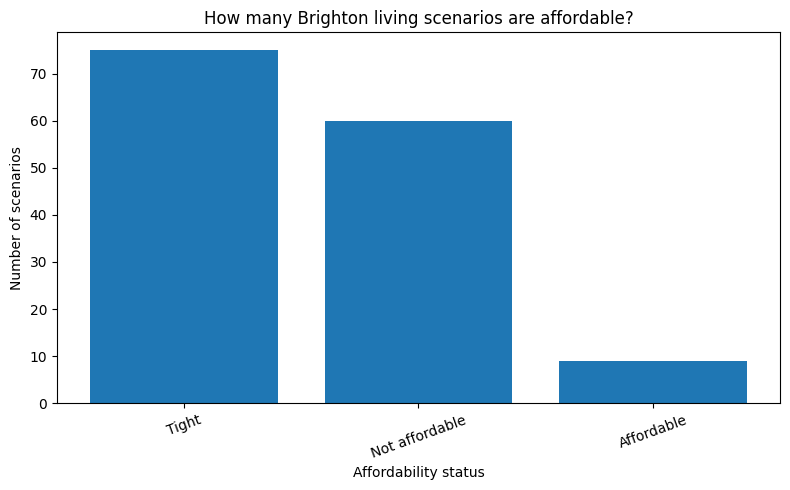

In [30]:
# ---------------------------------------------------------#
# Create a bar chart of affordability categories
# ---------------------------------------------------------#
plt.figure(figsize=(8, 5))

plt.bar(

    # Categories on the x-axis
    status_summary["affordability_status"],

    # Counts on the y-axis
    status_summary["scenario_count"]
)

# ---------------------------------------------------------#
# Add chart title and axis labels
# ---------------------------------------------------------#
plt.title(
    "How many Brighton living scenarios are affordable?"
)

plt.xlabel("Affordability status")

plt.ylabel("Number of scenarios")

# ---------------------------------------------------------#
# Improve chart readability
# ---------------------------------------------------------#

# Slightly rotate category labels
plt.xticks(rotation=20)

# Automatically adjust spacing
plt.tight_layout()

# ---------------------------------------------------------#
# Display the chart
# ---------------------------------------------------------#
plt.show()

## ✅ Checkpoint

You should now see a bar chart summarising the affordability outcomes.

The chart makes it easier to compare:
- affordable scenarios
- financially tight scenarios
- unaffordable scenarios

This is an important shift in the analytical workflow:

summary tables
→ visual interpretation
→ communication of findings

Visualisations help transform analytical results into information that can be understood more quickly and discussed more easily.

---


## 🧐 Step 4.4 — Focus on Shared Housing Scenarios

So far, we have looked at the overall affordability picture.

We will now focus specifically on:

`shared_room`

For many young people, shared accommodation is often the most realistic entry point into the housing market.

By narrowing the analysis, we can explore:
- which personas are most financially constrained
- how affordability differs between groups
- whether shared housing meaningfully changes the outcomes

This type of focused analysis is common in real-world projects, where analysts often investigate specific subgroups or scenarios in more detail.


In [31]:
# ---------------------------------------------------------#
# Filter the data to shared-room scenarios only
# ---------------------------------------------------------#
shared = affordability[
    affordability["rent_option"] == "shared_room"
].copy()

# ---------------------------------------------------------#
# Summarise affordability outcomes by persona
# ---------------------------------------------------------#
shared_summary = (

    shared

    # Group by persona and affordability category
    .groupby(["persona", "affordability_status"])

    # Count matching rows
    .size()

    # Convert counts into a dataframe column
    .reset_index(name="scenario_count")
)

# ---------------------------------------------------------#
# Display the summary table
# ---------------------------------------------------------#
display(shared_summary)

,persona,affordability_status,scenario_count
0,18-year-old apprentice,Not affordable,18
1,19-year-old retail worker,Tight,18
2,21-year-old full-time worker,Tight,18
3,23-year-old graduate analyst,Affordable,9
4,23-year-old graduate analyst,Tight,9


## ✅ Checkpoint

You should now see affordability outcomes for shared-room scenarios grouped by persona.

This allows us to compare how different groups experience affordability under similar housing conditions.

For example, we can begin exploring questions such as:

- Which personas still struggle even with shared housing?
- Which groups appear financially stable?
- How strongly does income level affect affordability?

This is an important analytical technique: moving from broad summaries toward more targeted investigation of specific groups and scenarios.

---


## 📈 Step 4.5 — Compare Financial Pressure Across Personas

We will now examine how much money each persona has left after covering:
- rent
- transport
- essential living costs

This remaining amount is stored in:

`monthly_leftover`

By calculating the average leftover amount for each persona, we can begin identifying:
- which groups are financially comfortable
- which groups are under pressure
- which groups may struggle to live independently in Brighton

This moves the analysis closer to answering the central workshop question:
"Who can realistically afford to live in Brighton?"

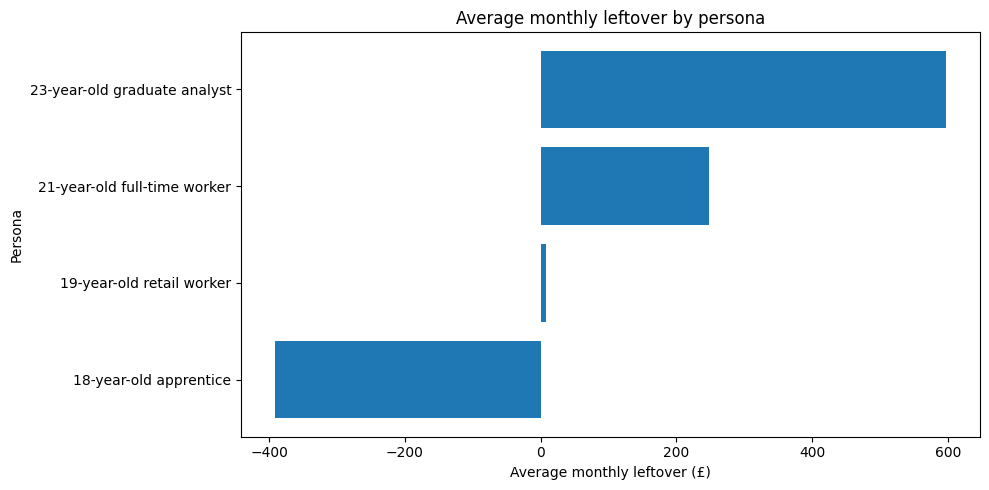

,persona,monthly_leftover
0,18-year-old apprentice,-392.0
1,19-year-old retail worker,8.0
2,21-year-old full-time worker,248.0
3,23-year-old graduate analyst,598.0


In [32]:
# ---------------------------------------------------------------#
# Calculate the average monthly leftover amount for each persona
# ---------------------------------------------------------------#
leftover_by_persona = (

    affordability

    # Group rows by persona
    .groupby("persona")["monthly_leftover"]

    # Calculate average leftover amount
    .mean()

    # Sort from lowest to highest
    .sort_values()

    # Convert the result back into a dataframe
    .reset_index()
)

# ---------------------------------------------------------#
# Create a horizontal bar chart
# ---------------------------------------------------------#
#
# Horizontal charts work well when category labels
# are relatively long.
#
plt.figure(figsize=(10, 5))

plt.barh(

    # Personas on the y-axis
    leftover_by_persona["persona"],

    # Average leftover values on the x-axis
    leftover_by_persona["monthly_leftover"]
)

# ---------------------------------------------------------#
# Add chart title and axis labels
# ---------------------------------------------------------#
plt.title("Average monthly leftover by persona")

plt.xlabel("Average monthly leftover (£)")

plt.ylabel("Persona")

# ---------------------------------------------------------#
# Improve chart layout
# ---------------------------------------------------------#
plt.tight_layout()

# ---------------------------------------------------------#
# Display the chart
# ---------------------------------------------------------#
plt.show()

# ---------------------------------------------------------#
# Display the numerical summary table
# ---------------------------------------------------------#
display(leftover_by_persona)

## ✅ Checkpoint

You should now see:
- a chart comparing average leftover income by persona
- a summary table containing the calculated values

This helps reveal which groups experience the greatest financial pressure after covering essential monthly costs.

Consider questions such as:

- Which persona appears most financially squeezed?
- Which groups retain meaningful disposable income?
- Which personas are close to financial instability?

This type of analysis helps move from data processing toward real-world social and economic interpretation.

---


## 📉 Step 4.6 — Compare Rent Burden across Personas and Housing Options

A common affordability measure is the **rent burden percentage** given by `rent ÷ income × 100`.

It estimates how much of a person’s income is consumed by rent. Higher percentages usually indicate greater financial pressure.

We will now compare:

- shared-room renting
- one-bedroom renting

across the different personas.

This helps us explore how strongly housing type affects affordability outcomes.


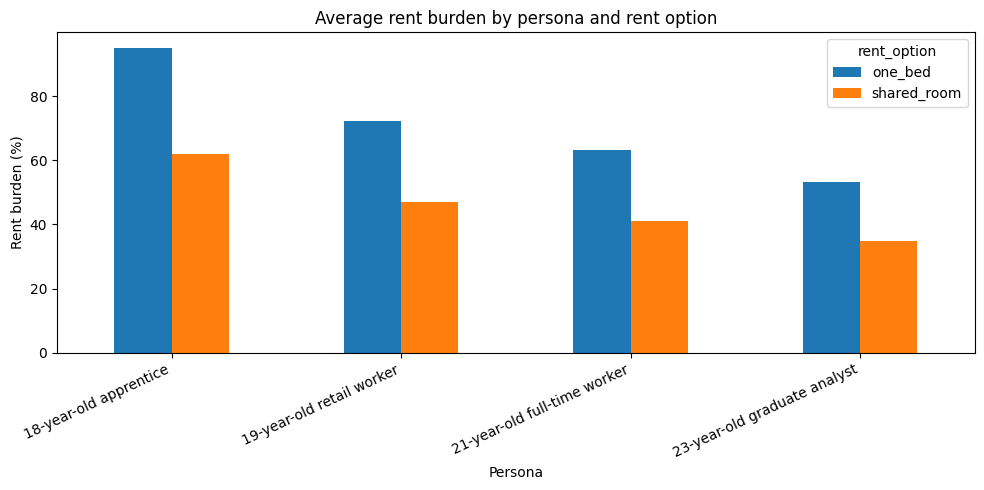

rent_option,one_bed,shared_room
persona,,
18-year-old apprentice,95.116667,62.050000
19-year-old retail worker,72.183333,47.100000
21-year-old full-time worker,63.083333,41.133333
23-year-old graduate analyst,53.266667,34.750000


In [33]:
# ---------------------------------------------------------#
# Calculate average rent burden percentages
# ---------------------------------------------------------#
rent_burden = (

    affordability

    # Group by persona and rent type
    .groupby(["persona", "rent_option"])["rent_burden_pct"]

    # Calculate average rent burden
    .mean()

    # Convert result into a dataframe
    .reset_index()
)

# ---------------------------------------------------------#
# Reshape the data for charting
# ---------------------------------------------------------#
#
# pivot() reorganises the dataframe so that:
#
# rows    -> personas
# columns -> rent options
# values  -> rent burden percentages
#
# This structure works well for grouped bar charts.
#
pivot_burden = rent_burden.pivot(
    index="persona",
    columns="rent_option",
    values="rent_burden_pct"
)

# ---------------------------------------------------------#
# Create the grouped bar chart
# ---------------------------------------------------------#
pivot_burden.plot(
    kind="bar",
    figsize=(10, 5)
)

# ---------------------------------------------------------#
# Add chart title and axis labels
# ---------------------------------------------------------#
plt.title(
    "Average rent burden by persona and rent option"
)

plt.xlabel("Persona")

plt.ylabel("Rent burden (%)")

# ---------------------------------------------------------#
# Improve chart readability
# ---------------------------------------------------------#
plt.xticks(rotation=25, ha="right")

plt.tight_layout()

# ---------------------------------------------------------#
# Display the chart
# ---------------------------------------------------------#
plt.show()

# ---------------------------------------------------------#
# Display the numerical summary table
# ---------------------------------------------------------#
display(pivot_burden)

## ✅ Checkpoint

You should now see:
- a chart comparing rent burden percentages
- a summary table showing the calculated values

The results should show that:
- one-bedroom renting places much greater financial pressure on most personas
- shared accommodation is often significantly more affordable

This highlights an important real-world insight:

housing affordability is influenced not only by income, but also by housing type and living arrangements.

Consider questions such as:
- Which personas are most affected by one-bedroom rents?
- Which groups appear most financially vulnerable?
- At what point does rent consume an unsustainable share of income?

These are the kinds of questions analysts and policymakers often investigate when studying affordability.

---


## ⚖️ Step 4.7 — Identify the Best Affordability Option for Each Persona

So far, we have looked at overall patterns:
- averages
- counts
- overall trends

We will now examine specific scenarios.

The goal is to identify which combinations of:
- area
- housing type
- transport option

produce the strongest affordability outcomes for each persona, after taking into account their:
- rent
- transport
- essential living costs

This helps answer a more practical question:

> “Given this person’s income, which Brighton living options look most realistic?”

This is where analysis starts turning into useful alternatives.


In [34]:
# ---------------------------------------------------------------------------#
# Sort scenarios so the best monthly leftover appears first for each persona
# ---------------------------------------------------------------------------#
best_options = (

    affordability

    # Sort each persona's scenarios from best to worst
    .sort_values(
        ["persona", "monthly_leftover"],
        ascending=[True, False]
    )

    # Keep only the top 5 scenarios for each persona
    .groupby("persona")
    .head(5)

    # Select the most relevant columns for inspection
    [[
        "persona",
        "area",
        "rent_option",
        "transport_option",
        "monthly_take_home_estimate",
        "monthly_rent",
        "monthly_transport_cost",
        "monthly_leftover",
        "rent_burden_pct",
        "affordability_status"
    ]]
)

# ---------------------------------------------------------#
# Display the strongest affordability scenarios
# ---------------------------------------------------------#
display(best_options)

,persona,area,rent_option,transport_option,monthly_take_home_estimate,monthly_rent,monthly_transport_cost,monthly_leftover,rent_burden_pct,affordability_status
120,18-year-old apprentice,Moulsecoomb,shared_room,walk_or_cycle,1260,680,20,-10.0,54.0,Not affordable
72,18-year-old apprentice,Kemptown,shared_room,walk_or_cycle,1260,760,20,-90.0,60.3,Not affordable
0,18-year-old apprentice,Brighton Centre,shared_room,walk_or_cycle,1260,775,20,-105.0,61.5,Not affordable
124,18-year-old apprentice,Moulsecoomb,shared_room,bus_commuter,1260,680,120,-110.0,54.0,Not affordable
128,18-year-old apprentice,Moulsecoomb,shared_room,daily_city_bus,1260,680,136,-126.0,54.0,Not affordable
121,19-year-old retail worker,Moulsecoomb,shared_room,walk_or_cycle,1660,680,20,390.0,41.0,Tight
73,19-year-old retail worker,Kemptown,shared_room,walk_or_cycle,1660,760,20,310.0,45.8,Tight
1,19-year-old retail worker,Brighton Centre,shared_room,walk_or_cycle,1660,775,20,295.0,46.7,Tight
125,19-year-old retail worker,Moulsecoomb,shared_room,bus_commuter,1660,680,120,290.0,41.0,Tight
129,19-year-old retail worker,Moulsecoomb,shared_room,daily_city_bus,1660,680,136,274.0,41.0,Tight


## ✅ Checkpoint

You should now see the top five living options for each persona.

This table is useful because it does not simply say:

“Brighton is expensive.”

Instead, it shows possible alternatives.

For each persona, we can now compare:

- which areas look more realistic
- which rent option works best
- how transport affects affordability
- how much money may be left each month

This is the kind of table that helps a stakeholder move from understanding the problem to considering possible decisions.

---


## 💻 Step 4.8 — Create a simple Streamlit dashboard application

Up to this point, the analysis has been explored mainly inside Jupyter Notebook cells. Now we will turn the analysis into a small interactive web app using Streamlit.

Streamlit allows us to turn the analytical model into a small interactive web application, that lives outside the Jupyter Notebook and can be shared with stakeholders and users.

The app will allow users to:
- choose a persona 
- choose a Brighton area
- choose a housing option
- choose a transport option

and immediately see the affordability outcome.

This is an important step because real analysis often needs to be presented in a way that helps other people explore options and make decisions.


In [35]:
import textwrap
from pathlib import Path

# ---------------------------------------------------------#
# Create the app output folder
# ---------------------------------------------------------#
app_dir = dbt_project_dir / "output" / "app"

app_dir.mkdir(parents=True, exist_ok=True)

# Path of the generated Streamlit app file
app_file = app_dir / "brighton_affordability_app.py"

# ---------------------------------------------------------#
# Streamlit application source code
# ---------------------------------------------------------#
#
# We build the app as a Python script stored in:
#
#     brighton_affordability_app.py
#
# The placeholder:
#
#     __DB_PATH__
#
# will later be replaced with the actual database path.
#

app_template = """
import duckdb
import pandas as pd
import streamlit as st

# -----------------------------------------------------#
# Configure Streamlit page settings
# -----------------------------------------------------#

st.set_page_config(
    page_title="Brighton Affordability Checker",
    layout="centered"
)

# -----------------------------------------------------#
# Application title and introduction
# -----------------------------------------------------#

st.title("🏠 Could You Afford Brighton?")

st.write(
    "Explore affordability scenarios using the DBT output model."
)

# -----------------------------------------------------#
# Connect to the DuckDB database
# -----------------------------------------------------#

db_path = r"__DB_PATH__"

con = duckdb.connect(db_path, read_only=True)

# Load the final analytical model into a dataframe
df = con.execute(
    "select * from mart_affordability_scenarios"
).fetchdf()

con.close()

# -----------------------------------------------------#
# Interactive user controls
# -----------------------------------------------------#

persona = st.selectbox(
    "Choose a persona",
    sorted(df["persona"].unique())
)

area = st.selectbox(
    "Choose an area",
    sorted(df["area"].unique())
)

rent_option = st.selectbox(
    "Choose a rent option",
    sorted(df["rent_option"].unique())
)

transport_option = st.selectbox(
    "Choose a transport option",
    sorted(df["transport_option"].unique())
)

# -----------------------------------------------------#
# Filter the dataframe using the selected options
# -----------------------------------------------------#

selected = df[
    (df["persona"] == persona)
    & (df["area"] == area)
    & (df["rent_option"] == rent_option)
    & (df["transport_option"] == transport_option)
]

# -----------------------------------------------------#
# Display the affordability result
# -----------------------------------------------------#

if not selected.empty:

    row = selected.iloc[0]

    st.subheader("Result")

    st.metric(
        "Monthly leftover",
        f"£{row['monthly_leftover']:.0f}"
    )

    st.metric(
        "Rent burden",
        f"{row['rent_burden_pct']:.1f}%"
    )

    status = row["affordability_status"]

    st.write(f"### Status: {status}")

    st.write("### Scenario details")

    st.dataframe(
        selected,
        use_container_width=True
    )

# -----------------------------------------------------#
# Footer note
# -----------------------------------------------------#

st.write("---")

st.caption(
    "Teaching app: figures are simplified workshop estimates based on public-source benchmarks."
)
"""

# ---------------------------------------------------------#
# Write the Streamlit app file to disk
# ---------------------------------------------------------#
app_file.write_text(

    textwrap.dedent(app_template).replace(
        "__DB_PATH__",
        str(database_path)
    ),

    encoding="utf-8"
)

# ---------------------------------------------------------#
# Final confirmation
# ---------------------------------------------------------#
print("✅ Streamlit app created:\n")

print(app_file)


✅ Streamlit app created:

/home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability/output/app/brighton_affordability_app.py


### ✅ Checkpoint

You should now have a Streamlit app file created at:

`dbt_projects/p01_affordability/output/app/brighton_affordability_app.py`

This app uses the final DBT model:

`mart_affordability_scenarios`

The notebook created the app, but it has not launched it yet.


## 🚀 Step 4.9 — Launch the Streamlit app from inside the notebook

Streamlit normally runs from a terminal command such as:

    streamlit run app.py

Here we launch it from the notebook using subprocess.

The app will run in the background as a small local web application that you can open in your browser using the printed local address.


In [36]:
import subprocess
import time

# ---------------------------------------------------------#
# Close any open DuckDB connection
# ---------------------------------------------------------#
#
# This helps avoid database lock issues.
#
try:
    con.close()
    print("✅ Closed existing DuckDB connection")
except Exception:
    pass

# ---------------------------------------------------------#
# Stop any earlier Streamlit app process
# ---------------------------------------------------------#
#
# If this cell is run more than once, an earlier app may
# still be using port 8501.
#
# We stop it first to avoid port conflicts.
#
try:
    streamlit_process.terminate()
    print("✅ Stopped previous Streamlit process")
except Exception:
    pass

# ---------------------------------------------------------#
# Start Streamlit as a background process
# ---------------------------------------------------------#
#
# We use:
#
#     venv_python -m streamlit run ...
#
# so that Streamlit runs from the workshop virtual environment.
#
# Options:
#
# --server.address=0.0.0.0
#     makes the app easier to access from environments such
#     as Chromebook Linux containers
#
# --server.port=8501
#     uses Streamlit's standard default port
#
# --server.headless=true
#     prevents Streamlit trying to open a browser itself
#
# --browser.gatherUsageStats=false
#     avoids the onboarding email prompt
#
streamlit_process = subprocess.Popen(
    [
        str(venv_python),
        "-m",
        "streamlit",
        "run",
        str(app_file),
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.headless=true",
        "--browser.gatherUsageStats=false",
    ],
    cwd=str(repo_root),
)

# Give Streamlit a few seconds to start
time.sleep(3)

# ---------------------------------------------------------#
# Display browser links
# ---------------------------------------------------------#
print("✅ Streamlit is starting")
print()
print("Open one of these links in your browser:")
print("http://localhost:8501")
print("http://127.0.0.1:8501")
print()
print("If you are using a Chromebook/Linux container and those do not work,")
print("ask your instructor for help with the container address.")


✅ Closed existing DuckDB connection


2026-05-15 19:05:50.331 Uvicorn server started on 0.0.0.0:8501



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://100.115.92.198:8501
  External URL: http://89.37.175.140:8501

✅ Streamlit is starting

Open one of these links in your browser:
http://localhost:8501
http://127.0.0.1:8501

If you are using a Chromebook/Linux container and those do not work,
ask your instructor for help with the container address.


2026-05-15 19:06:03.724 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.


### ✅ Checkpoint

The Streamlit app should now be running.

Open:

`http://localhost:8501`

or:

`http://127.0.0.1:8501`

You should see an interactive affordability checker.

Try changing the persona, area, rent option, and transport option.

This is the final move from analysis to presentation:

notebook analysis  →   interactive decision-support app


## 🛑 Step 4.10 — Stop the Streamlit App

When you are finished testing the app, stop the background Streamlit process.

This frees the port and avoids leaving the app running unnecessarily.


In [37]:
# ---------------------------------------------------------#
# Stop the running Streamlit application
# ---------------------------------------------------------#
try:

    streamlit_process.terminate()
    print("✅ Streamlit app stopped")

except Exception:

    # Happens if:
    # - the app was never started
    # - the process was already stopped
    # - the variable does not exist
    #
    print("No Streamlit process was found")

✅ Streamlit app stopped
  Stopping...


## ✍️ Step 4.11 — Generate simple Analytical Findings automatically

We have explored the data, created charts, and compared affordability scenarios.

We now move toward interpretation.

Analysts often calculate a few headline findings that help summarise the main story emerging from the data.

A good finding is:
- based on evidence
- easy to understand
- useful for decision-making

In this step, we will generate a few simple findings automatically from the data.


In [38]:
# ---------------------------------------------------------#
# Calculate how many scenarios are "Not affordable"
# ---------------------------------------------------------#

not_affordable_count = int(

    (
        affordability["affordability_status"]
        == "Not affordable"
    ).sum()
)

# Total number of analysed scenarios
total_count = len(affordability)

# Convert the count into a percentage
not_affordable_pct = round(
    not_affordable_count * 100 / total_count,
    1
)

# ---------------------------------------------------------#
# Identify the most financially stretched persona
# ---------------------------------------------------------#
#
# leftover_by_persona was previously sorted from:
#
# lowest leftover
# → highest leftover
#
# so the first row represents the persona under the
# greatest financial pressure.
#

most_stretched = leftover_by_persona.iloc[0]["persona"]

# ---------------------------------------------------------#
# Identify the lowest-rent area in the source data
# ---------------------------------------------------------#
#
# We calculate the average monthly rent for each area
# and select the lowest value.
#

lowest_rent_area = (

    rents
    .groupby("area")["monthly_rent"]
    .mean()
    .sort_values()
    .index[0]
)

# ---------------------------------------------------------#
# Display the generated findings
# ---------------------------------------------------------#

print("Automatic findings:")
print()

print(
    f"1. {not_affordable_pct}% of scenarios "
    f"are classified as not affordable."
)

print(
    f"2. The most financially stretched persona is: "
    f"{most_stretched}."
)

print(
    f"3. The area with the lowest average rent "
    f"in this teaching dataset is: {lowest_rent_area}."
)


Automatic findings:

1. 41.7% of scenarios are classified as not affordable.
2. The most financially stretched persona is: 18-year-old apprentice.
3. The area with the lowest average rent in this teaching dataset is: Moulsecoomb.


### ✅ Checkpoint

You should now see three automatically generated findings.

These findings are not the final answer by themselves.

They are evidence points that help us explain:
- what the data suggests
- who may be most affected
- which options might deserve attention

The next step is to connect these findings to possible stakeholder decisions.

---



## ⚖️ Step 4.12 — Frame Alternatives for a Stakeholder

A stakeholder does not only need facts.

They need realistic choices.

For example, the data might suggest that Brighton affordability pressure could be addressed in several different ways:

| Option | What it means | Who it may help |
|---|---|---|
| Shared housing support | Help young people access safe, reliable shared housing | Apprentices and lower-paid workers |
| Transport support | Reduce the cost of travelling to work or study | People living farther from central Brighton |
| Local wage partnerships | Encourage employers to improve early-career pay | Young full-time workers |
| Affordable starter housing | Expand lower-cost rental options | Young people trying to live independently |
| Career pathway support | Help young residents move into higher-paid digital and analytical roles | Students and early-career workers |

This is where analysis becomes decision support.

The analyst does not make the final policy decision.

The analyst helps stakeholders understand the evidence and compare possible actions.

## 📜 Step 4.13 — Create a Stakeholder Summary Report

Analytical work often ends with communication.

The goal is not only to produce tables and charts,
but also to explain:

- what was investigated
- what was discovered
- what decisions might be considered

Here we generate a short Markdown report that summarises:
- the analytical question
- the datasets used
- the main findings
- possible stakeholder responses

The report is saved as a reusable project artifact.

This is the kind of short summary that an analyst might share with a manager, sponsor, council officer, or community stakeholder.


In [39]:
# ---------------------------------------------------------#
# Ensure the reports folder exists
# ---------------------------------------------------------#
reports_dir = output_dir / "reports"

reports_dir.mkdir(parents=True, exist_ok=True)

# Path of the generated report
summary_file = reports_dir / "brighton_affordability_summary.md"

# ---------------------------------------------------------#
# Build the report text
# ---------------------------------------------------------#
summary_text = f"""# Brighton Affordability Analysis Summary

## Question

Can young people still afford to live in Brighton?

## Data Used

This analysis used prepared workshop datasets based on public-source benchmarks for:

- Brighton rents
- young worker income scenarios
- essential living costs
- transport cost scenarios

## Key Findings

1. {not_affordable_pct}% of modelled scenarios were classified as **not affordable**.
2. The most financially stretched persona was: **{most_stretched}**.
3. The area with the lowest average rent in this teaching dataset was: **{lowest_rent_area}**.

## Decision Alternatives

Stakeholders could consider:

1. Supporting safe shared housing options for young people.
2. Improving transport affordability for young workers.
3. Working with local employers on better early-career pay.
4. Expanding affordable starter housing options.
5. Helping young people access higher-paid digital and analytical career pathways.

## Important Caveat

This is a workshop model.

The data is simplified for teaching and should be replaced with fuller official datasets before making real policy or funding decisions.

## Portfolio Note

This project demonstrates a complete beginner-friendly data workflow:

- data preparation
- DBT transformation
- data validation
- exploratory analysis
- visualisation
- stakeholder reporting
"""

# ---------------------------------------------------------#
# Save the report to disk
# ---------------------------------------------------------#
summary_file.write_text(
    summary_text,
    encoding="utf-8"
)

# ---------------------------------------------------------#
# Display the report location and contents
# ---------------------------------------------------------#
print("✅ Summary report written:")

print(summary_file)
print()
print(summary_text)


✅ Summary report written:
/home/michaelliedl/Prj/Data-Analytics/dbt-workshop/dbt_projects/p01_affordability/output/reports/brighton_affordability_summary.md

# Brighton Affordability Analysis Summary

## Question

Can young people still afford to live in Brighton?

## Data Used

This analysis used prepared workshop datasets based on public-source benchmarks for:

- Brighton rents
- young worker income scenarios
- essential living costs
- transport cost scenarios

## Key Findings

1. 41.7% of modelled scenarios were classified as **not affordable**.
2. The most financially stretched persona was: **18-year-old apprentice**.
3. The area with the lowest average rent in this teaching dataset was: **Moulsecoomb**.

## Decision Alternatives

Stakeholders could consider:

1. Supporting safe shared housing options for young people.
2. Improving transport affordability for young workers.
3. Working with local employers on better early-career pay.
4. Expanding affordable starter housing options.


### ✅ Checkpoint

You should now have a stakeholder summary report saved at:

`dbt_projects/p01_affordability/output/reports/brighton_affordability_summary.md`

This report is one of your final workshop outputs.

It is useful because it shows not only that you ran code, but that you used data to support a real-world decision question.

That is the difference between:
- producing data
- and communicating insight

---



## 🎉 Workshop Complete — What You Have Achieved

You have now completed a full beginner-to-analyst data workflow using modern analytical tools and practices.

During this workshop, you:

✅ created a structured analytical project  
✅ worked with real-style datasets  
✅ created and managed a DBT project  
✅ loaded source data into DuckDB  
✅ built transformation models using SQL and DBT  
✅ applied automated data quality validation tests  
✅ generated analytical models for decision support  
✅ queried and explored data using Python and Pandas  
✅ created charts and visualisations with Matplotlib  
✅ built an interactive dashboard using Streamlit  
✅ generated stakeholder-style findings and reports  
✅ explored DBT lineage graphs and project documentation  

Most importantly, you experienced something extremely important:

> Data Analysis is not only about writing code.

It is about:
- asking questions
- structuring information
- validating data
- interpreting evidence
- communicating findings
- supporting decisions

You have now seen how a modern analytical pipeline works from:

raw data  
→ transformation  
→ validation  
→ analysis  
→ visualisation  
→ communication  

That is the foundation of real-world analytics engineering and data analysis work.



## 🏗️ Suggested Next Practical Projects

To strengthen your skills, try building projects such as:

- local housing affordability studies
- transport accessibility analysis
- retail sales dashboards
- environmental monitoring projects
- public open-data dashboards
- city infrastructure analysis
- public health visualisations

The fastest way to improve is to:
- build projects
- publish them on GitHub
- explain your findings clearly
- iterate repeatedly

Be sure to look at the notebooks in:

`04_next_steps/`

where you will find guidance for further study 📚 and links to resources 🌐.


---

## 🚀 Final Thought

Professional analysts are not defined by memorising tools.

They are defined by the ability to:

- structure problems
- work with imperfect data
- think critically
- communicate clearly
- help people make better decisions

The tools will continue to evolve.

Those analytical habits are what truly matter.

---



#### Licence

This notebook is part of the **DBT Workshop — From Data Collection to Data Decision**,  
created by **Michael Liedl** in support of **Brighton Data Forum** workshop activity.

See the repository `LICENSE.md` and `CONTENT_LICENSE.md` files for reuse and attribution details.